### Notebook modelo de árbol de decisión y vecinos cercanos

En esta sesión nos concentraremos en la aplicación práctica de ambos modelos usando un pequeño conjunto de datos de habitabilidad de exoplanetas.

**Objetivos:**
- entrenar un **árbol de decisión** y un clasificador **kNN** con `scikit-learn`,
- interpretar predicciones y calcular `accuracy`,
- comparar ambos métodos en un mismo problema,
- entender por qué **kNN requiere escalamiento** de variables y los árboles no necesariamente.


(Adaptado de  Viviana Acquaviva (2023))



## Decision Trees

https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html


https://www.kaggle.com/code/willkoehrsen/visualize-a-decision-tree-w-python-scikit-learn

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

In [2]:
font = {'size'   : 20}
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=20)
matplotlib.rc('ytick', labelsize=20)
matplotlib.rcParams['figure.dpi'] = 300

In [3]:
#Paquetes para visualización

from io import StringIO
from IPython.display import Image
import pydotplus

from sklearn.tree import export_graphviz

### Subconjunto de base de datos de Habitabilidad de planetas https://phl.upr.edu/projects/habitable-exoplanets-catalog

In [4]:
LearningSet = pd.read_csv('HPLearningSet.csv', index_col=0)

**Variables:**
- `S_MASS`: masa estelar ($M_\odot$)
- `P_PERIOD`: período orbital (días)
- `P_DISTANCE`: distancia planeta–estrella (AU)
- `P_HABITABLE`: clase objetivo (0 = no habitable, 1 = habitable)


In [5]:
LearningSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
0,Kepler-736 b,0.86,3.601472,0.043718,0
1,Kepler-636 b,0.85,16.080661,0.118082,0
2,Kepler-887 c,1.19,7.638460,0.080420,0
3,Kepler-442 b,0.61,112.305300,0.409327,1
4,Kepler-772 b,0.98,12.992073,0.107408,0
5,Teegarden's Star b,0.09,4.910000,0.025200,1
6,K2-116 b,0.69,4.655411,0.048086,0
7,GJ 1061 c,0.12,6.689000,0.035000,1
8,HD 68402 b,1.12,1103.000000,2.180981,0
9,Kepler-1544 b,0.81,168.811170,0.557107,1


### Haga una revisión rápida del set de datos
- Encuentre el tamaño del dataset, y las categorías de la variable `P_HABITABLE` y los ejemplos en cada categoría.
- También visualice la relación entre la masa, el periodo y la habitabilidad del planeta. Grafique el periodo en escala log

Tamaño del dataset: (18, 5)
Categorías de P_HABITABLE y ejemplos en cada categoría:
P_HABITABLE
0    10
1     8
Name: count, dtype: int64


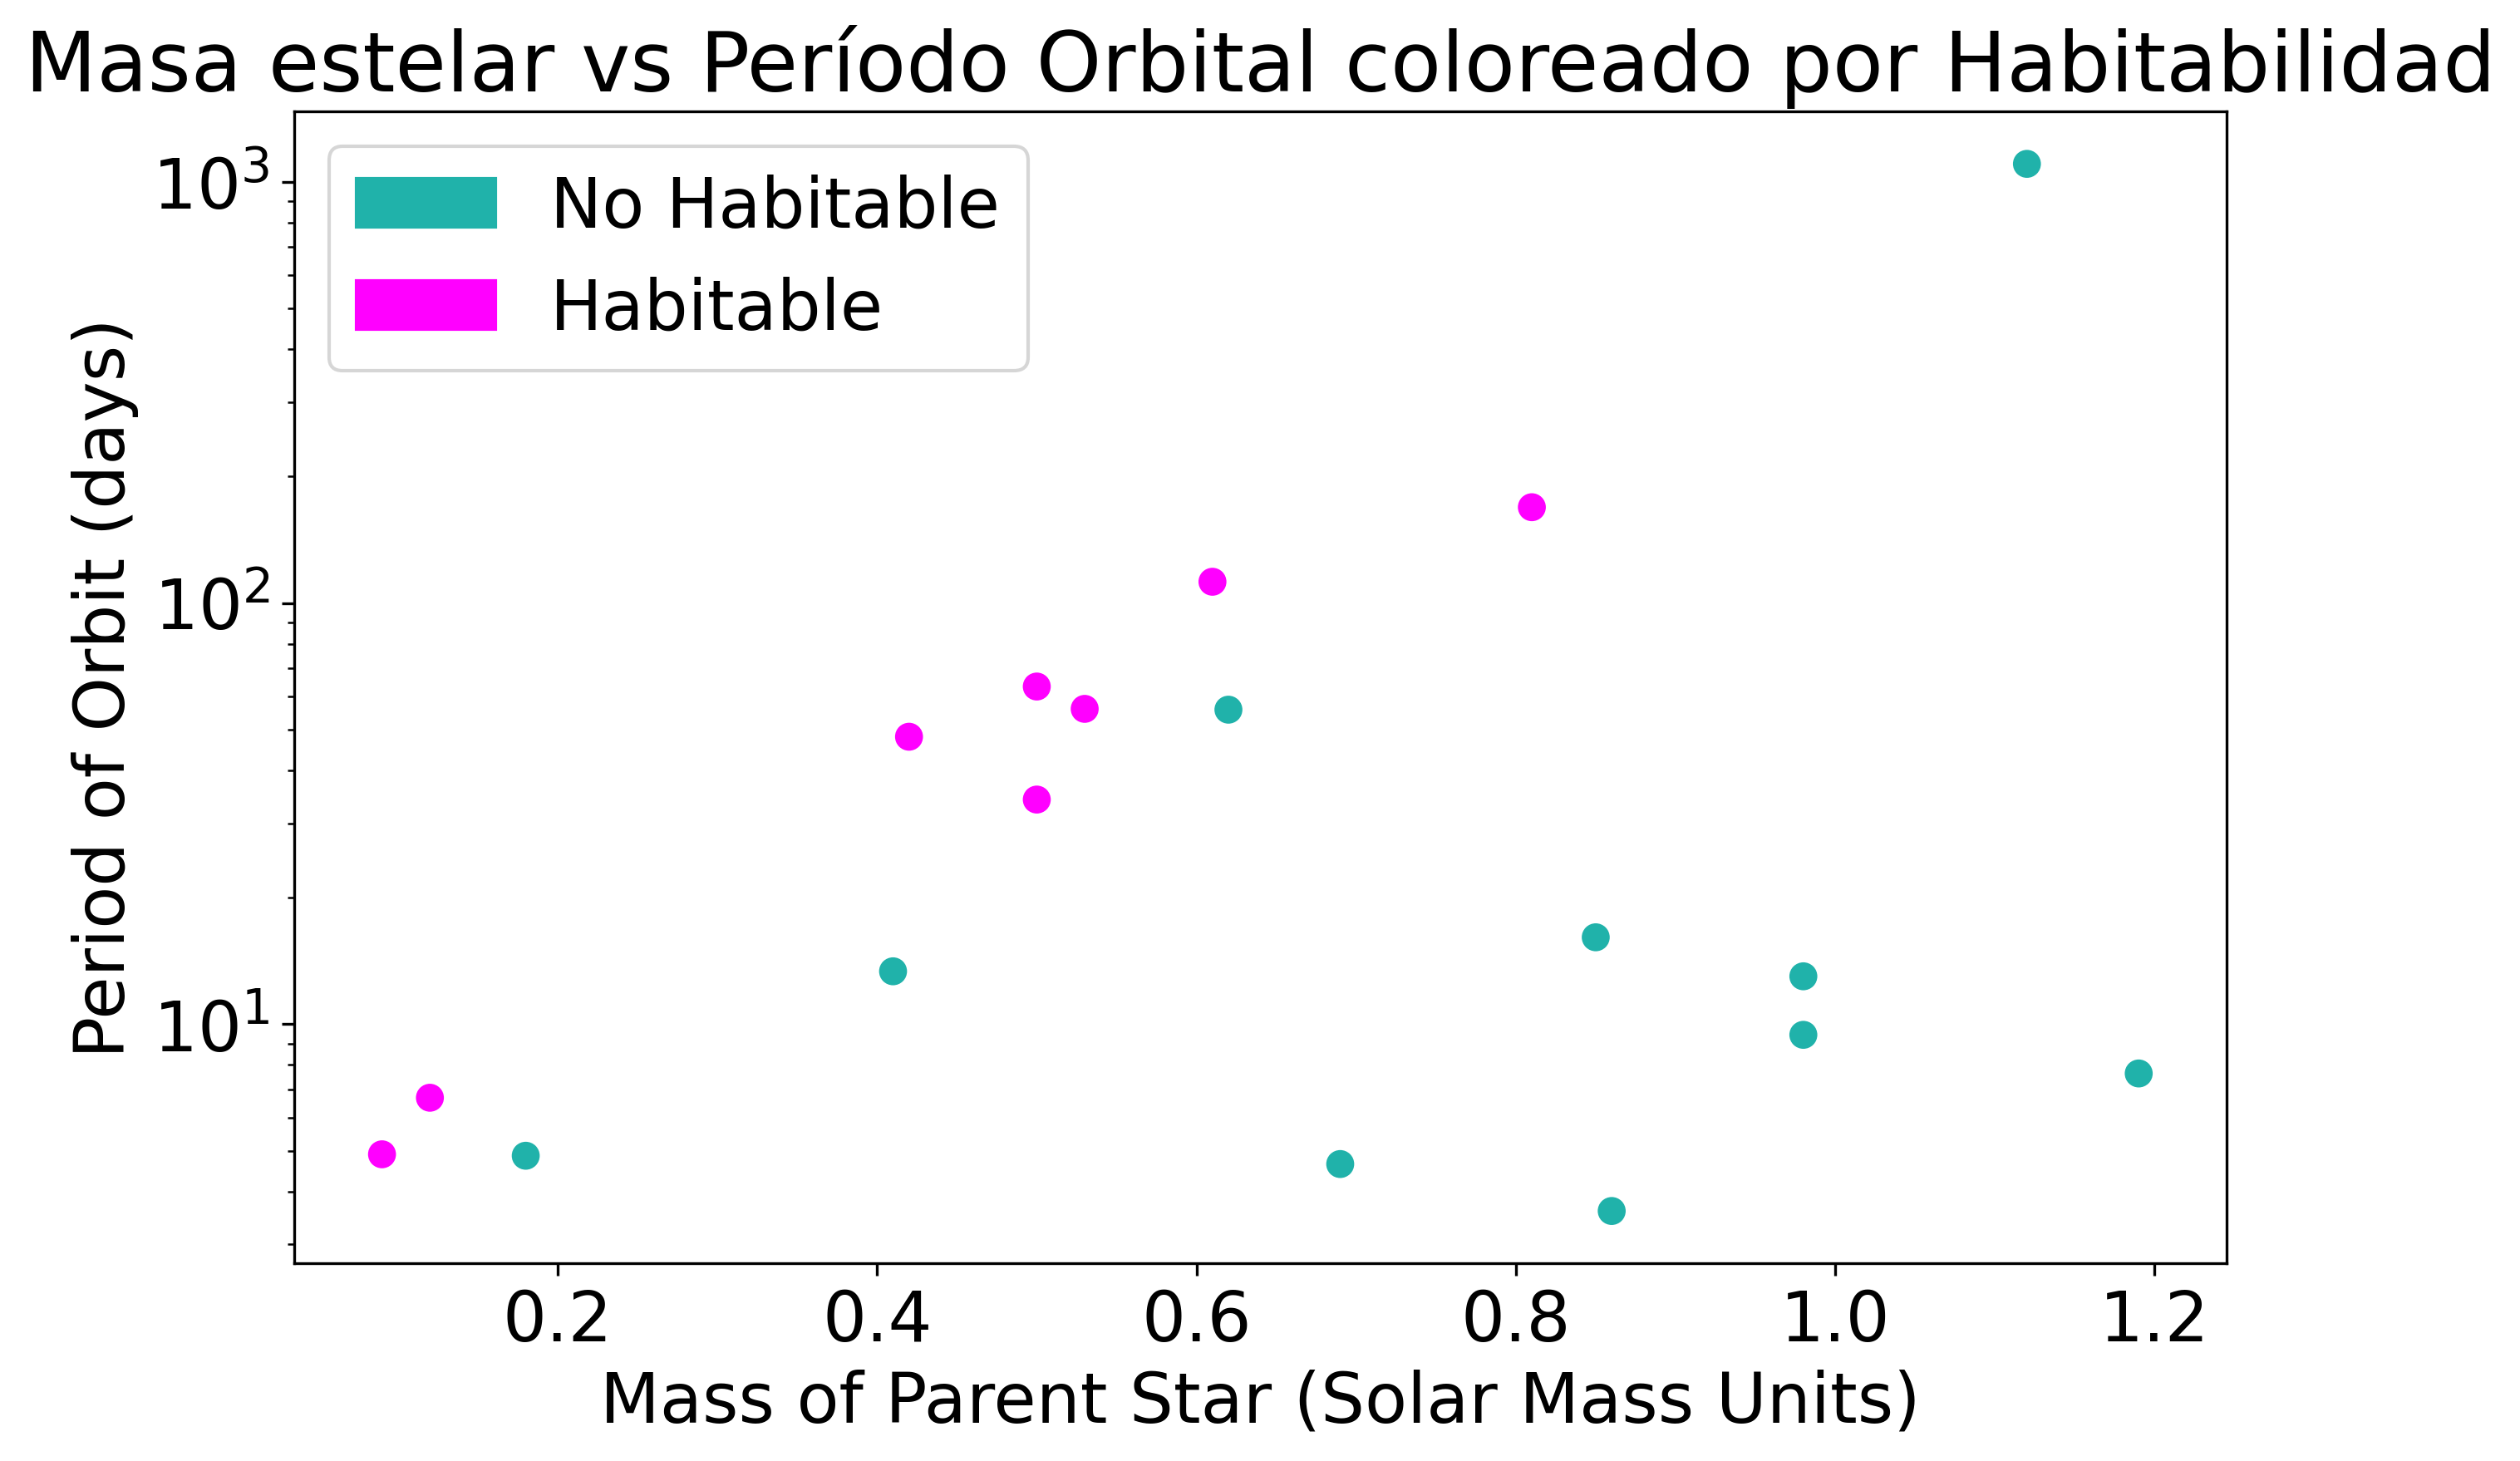

In [6]:
print(f"Tamaño del dataset: {LearningSet.shape}")
print("Categorías de P_HABITABLE y ejemplos en cada categoría:")
print(LearningSet['P_HABITABLE'].value_counts())

plt.figure(figsize=(10, 6))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#20B2AA','#FF00FF'])
plt.scatter(LearningSet['S_MASS'], LearningSet['P_PERIOD'], c=LearningSet['P_HABITABLE'], cmap=cmap, s=50)
plt.yscale('log')
plt.xlabel('Mass of Parent Star (Solar Mass Units)')
plt.ylabel('Period of Orbit (days)')
plt.title('Masa estelar vs Período Orbital coloreado por Habitabilidad')
bluepatch = mpatches.Patch(color='#20B2AA', label='No Habitable')
magentapatch = mpatches.Patch(color='#FF00FF', label='Habitable')
plt.legend(handles=[bluepatch, magentapatch])
plt.show()

**Antes de entrenar un modelo, te parece que las clases se separan fácilmente o no? Explique**  
Respuesta:  
No, las clases no se separan fácilmente. Si realizamos un análisis exploratorio visualizando pares de variables (como la masa estelar frente al periodo orbital o la distancia), los exoplanetas habitables y no habitables presentan un claro solapamiento. No existe una frontera de separación lineal simple o un único parámetro que corte limpiamente ambos grupos. Debido a esta complejidad multidimensional en el espacio de características, resulta esencial utilizar algoritmos capaces de modelar fronteras de decisión no lineales, como es el caso de kNN y los árboles de decisión, para poder capturar los verdaderos patrones geométricos que definen la habitabilidad.


### Elijamos el set de entrenamiento y prueba

Para definir los sets de etrenamiento y prueba, haremos una división *manual*

Definimos que las primeras 13 filas del dataframe será el conjunto de entrenamiento y los últimos 5, el conjunto de prueba

> En un problema real, usualmente preferimos una división aleatoria o validación cruzada.


Usaremos .iloc para acceder a los índices del dataframe

In [7]:
LearningSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
0,Kepler-736 b,0.86,3.601472,0.043718,0
1,Kepler-636 b,0.85,16.080661,0.118082,0
2,Kepler-887 c,1.19,7.638460,0.080420,0
3,Kepler-442 b,0.61,112.305300,0.409327,1
4,Kepler-772 b,0.98,12.992073,0.107408,0
5,Teegarden's Star b,0.09,4.910000,0.025200,1
6,K2-116 b,0.69,4.655411,0.048086,0
7,GJ 1061 c,0.12,6.689000,0.035000,1
8,HD 68402 b,1.12,1103.000000,2.180981,0
9,Kepler-1544 b,0.81,168.811170,0.557107,1


In [8]:
TrainSet =  LearningSet.iloc[:13,:]

TestSet = LearningSet.iloc[13:,:]

In [9]:
TrainSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
0,Kepler-736 b,0.86,3.601472,0.043718,0
1,Kepler-636 b,0.85,16.080661,0.118082,0
2,Kepler-887 c,1.19,7.638460,0.080420,0
3,Kepler-442 b,0.61,112.305300,0.409327,1
4,Kepler-772 b,0.98,12.992073,0.107408,0
5,Teegarden's Star b,0.09,4.910000,0.025200,1
6,K2-116 b,0.69,4.655411,0.048086,0
7,GJ 1061 c,0.12,6.689000,0.035000,1
8,HD 68402 b,1.12,1103.000000,2.180981,0
9,Kepler-1544 b,0.81,168.811170,0.557107,1


In [10]:
TestSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
13,HD 104067 b,0.62,55.80600,0.260000,0
14,GJ 4276 b,0.41,13.35200,0.087613,0
15,Kepler-296 f,0.50,63.33627,0.268885,1
16,Kepler-63 b,0.98,9.43415,0.088100,0
17,GJ 3293 d,0.42,48.13450,0.195336,1


También necesitamos definir para cada conjunto las características (features) y los objetivos (targets)

In [11]:
Xtrain = TrainSet.drop(['P_NAME','P_HABITABLE'],axis=1) #features conjunto de entrenamiento

Xtest = TestSet.drop(['P_NAME','P_HABITABLE'],axis=1) #features  conjunto de entrenamiento

In [12]:
Xtrain.columns

Index(['S_MASS', 'P_PERIOD', 'P_DISTANCE'], dtype='object')

In [13]:
ytrain = TrainSet.P_HABITABLE #target conjunto prueba

ytest = TestSet.P_HABITABLE  #target conjunto prueba

In [14]:
Xtest

,S_MASS,P_PERIOD,P_DISTANCE
13,0.62,55.80600,0.260000
14,0.41,13.35200,0.087613
15,0.50,63.33627,0.268885
16,0.98,9.43415,0.088100
17,0.42,48.13450,0.195336


In [15]:
ytrain

,P_HABITABLE
0,0
1,0
2,0
3,1
4,0
5,1
6,0
7,1
8,0
9,1


### Entrenamos el modelo
Nota: En los árboles de decisión de scikit-learn, las características (o variables) se reorganizan aleatoriamente cada vez que se realiza una división para decidir cómo separar los datos. Esto significa que, incluso si se usa el mismo conjunto de datos de entrenamiento, la mejor forma de dividir los datos puede cambiar entre diferentes ejecuciones del modelo. Esta variación ocurre cuando varias divisiones posibles ofrecen la misma mejora en el criterio de evaluación (por ejemplo, reducir la impureza del nodo). En estos casos, el algoritmo puede elegir diferentes divisiones como "mejores" en diferentes ejecuciones debido al orden aleatorio en que se evalúan las características.

Para asegurar que los resultados del entrenamiento sean consistentes y reproducibles (es decir, que se obtenga el mismo árbol de decisión cada vez que se entrene con los mismos datos), es necesario fijar el parámetro random_state. Esto establece una semilla para el generador de números aleatorios utilizado por el algoritmo, garantizando que la permutación de las características sea la misma en cada ejecución y, por lo tanto, el resultado del modelo también sea el mismo.

In [16]:
from sklearn.tree import DecisionTreeClassifier #modelo de árbol de decisión


In [17]:
model = DecisionTreeClassifier(random_state = 3) #Inicializamos el modelo con sus parámetros

model.fit(Xtrain, ytrain) #En una línea, construimos el modelo

DecisionTreeClassifier(random_state=3)

### Podemos visualizar el árbol (visualización "pro")

debe instalar la libreria [`pydotplus`](https://pypi.org/project/pydotplus/)  y [`graphviz`](https://pypi.org/project/graphviz/)

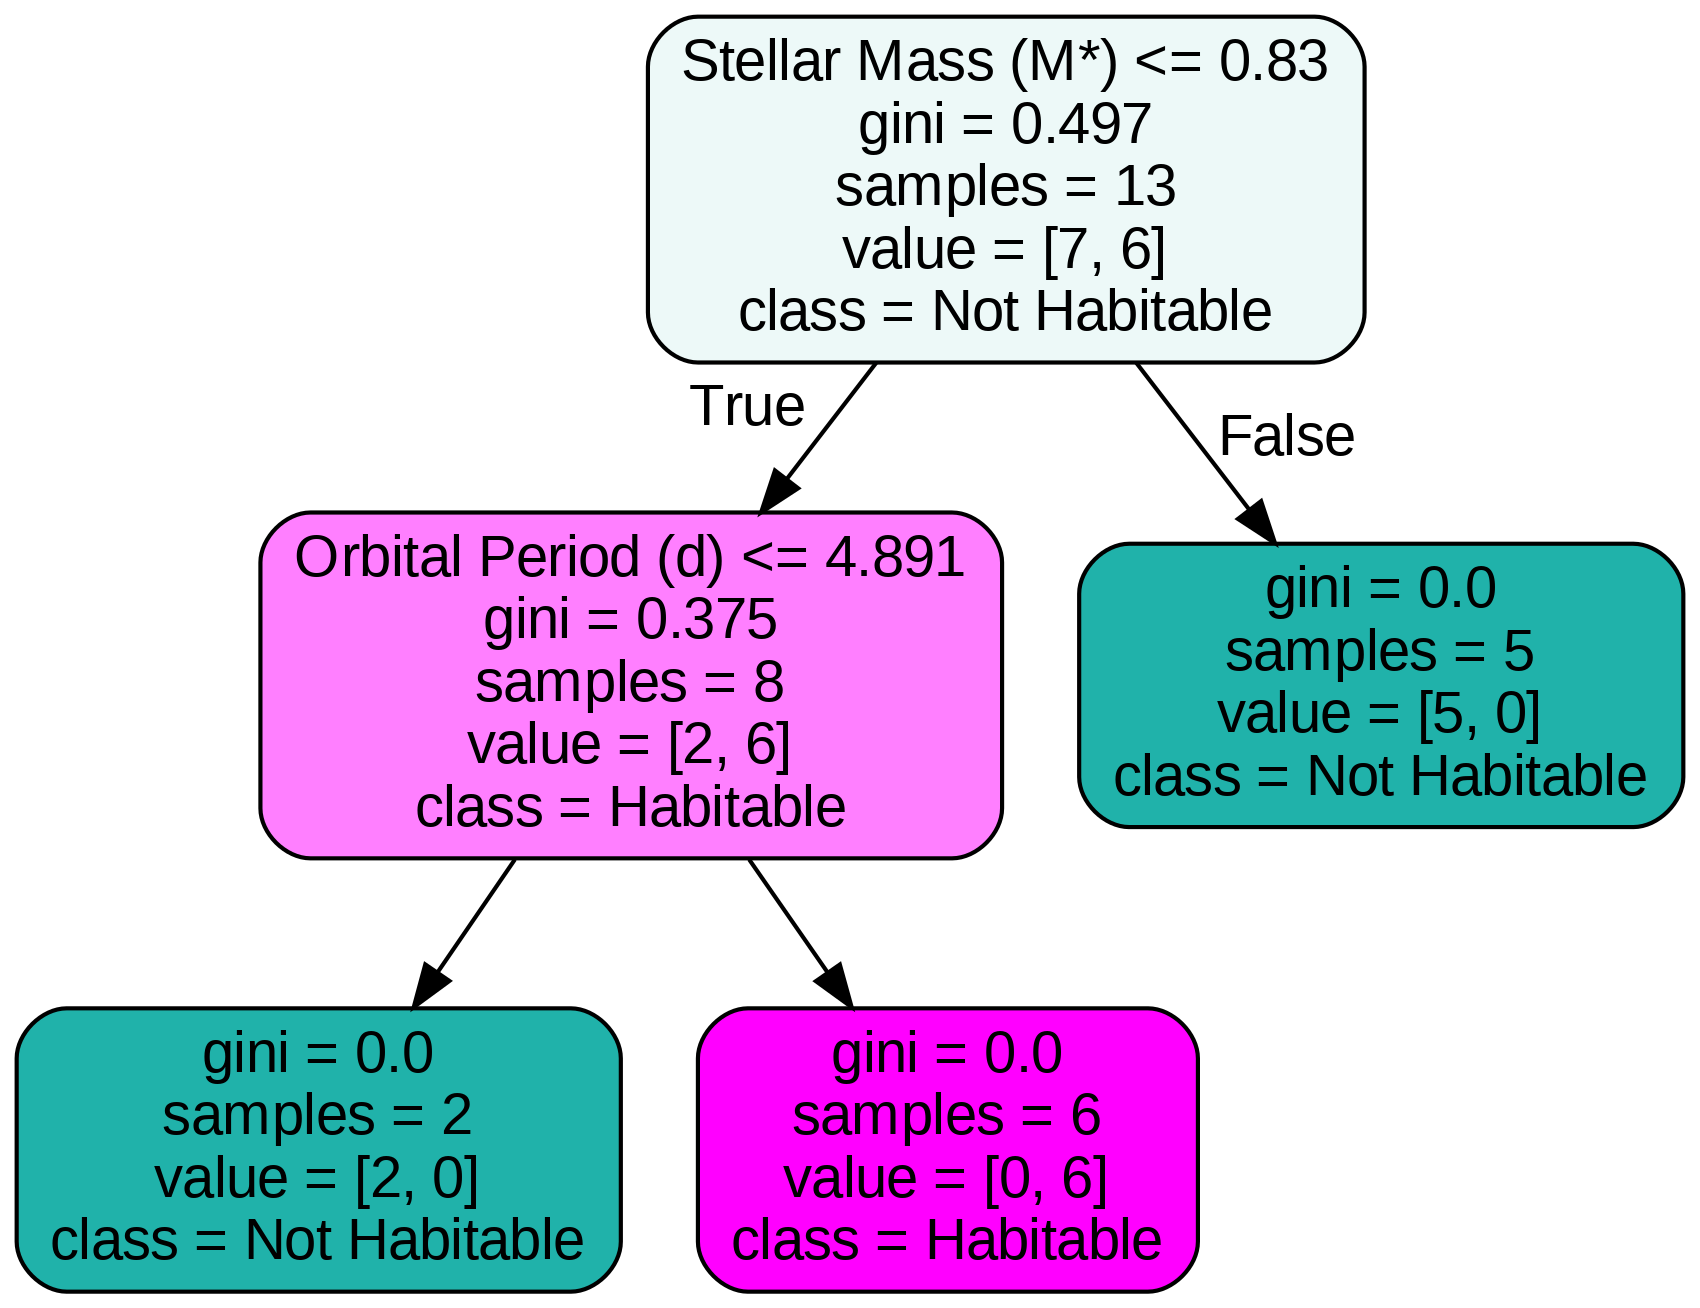

In [18]:
dot_data = StringIO()
export_graphviz(
            model,
            out_file =  dot_data,
            feature_names = ['Stellar Mass (M*)', 'Orbital Period (d)', 'Distance (AU)'],
            class_names = ['Not Habitable','Habitable'],
            filled = True,
            rounded = True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue().replace("\n", ""))
nodes = graph.get_node_list()

for node in nodes:
    if node.get_label():
        values = [int(ii) for ii in node.get_label().split('value = [')[1].split(']')[0].split(',')]
        values = [255 * v / sum(values) for v in values]

        values = [int(255 * v / sum(values)) for v in values]

        if values[0] > values[1]:
            alpha = int(values[0] - values[1])
            alpha = '{:02x}'.format(alpha) #turn into hexadecimal
            color = '#20 B2 AA'+str(alpha)
        else:
            alpha = int(values[1] - values[0])
            alpha = '{:02x}'.format(alpha)
            color = '#FF 00 FF'+str(alpha)
        node.set_fillcolor(color)

graph.set_dpi('300')

Image(graph.create_png())

#Image(graph.write_png('Graph.png'))

### Visualización de sklearn

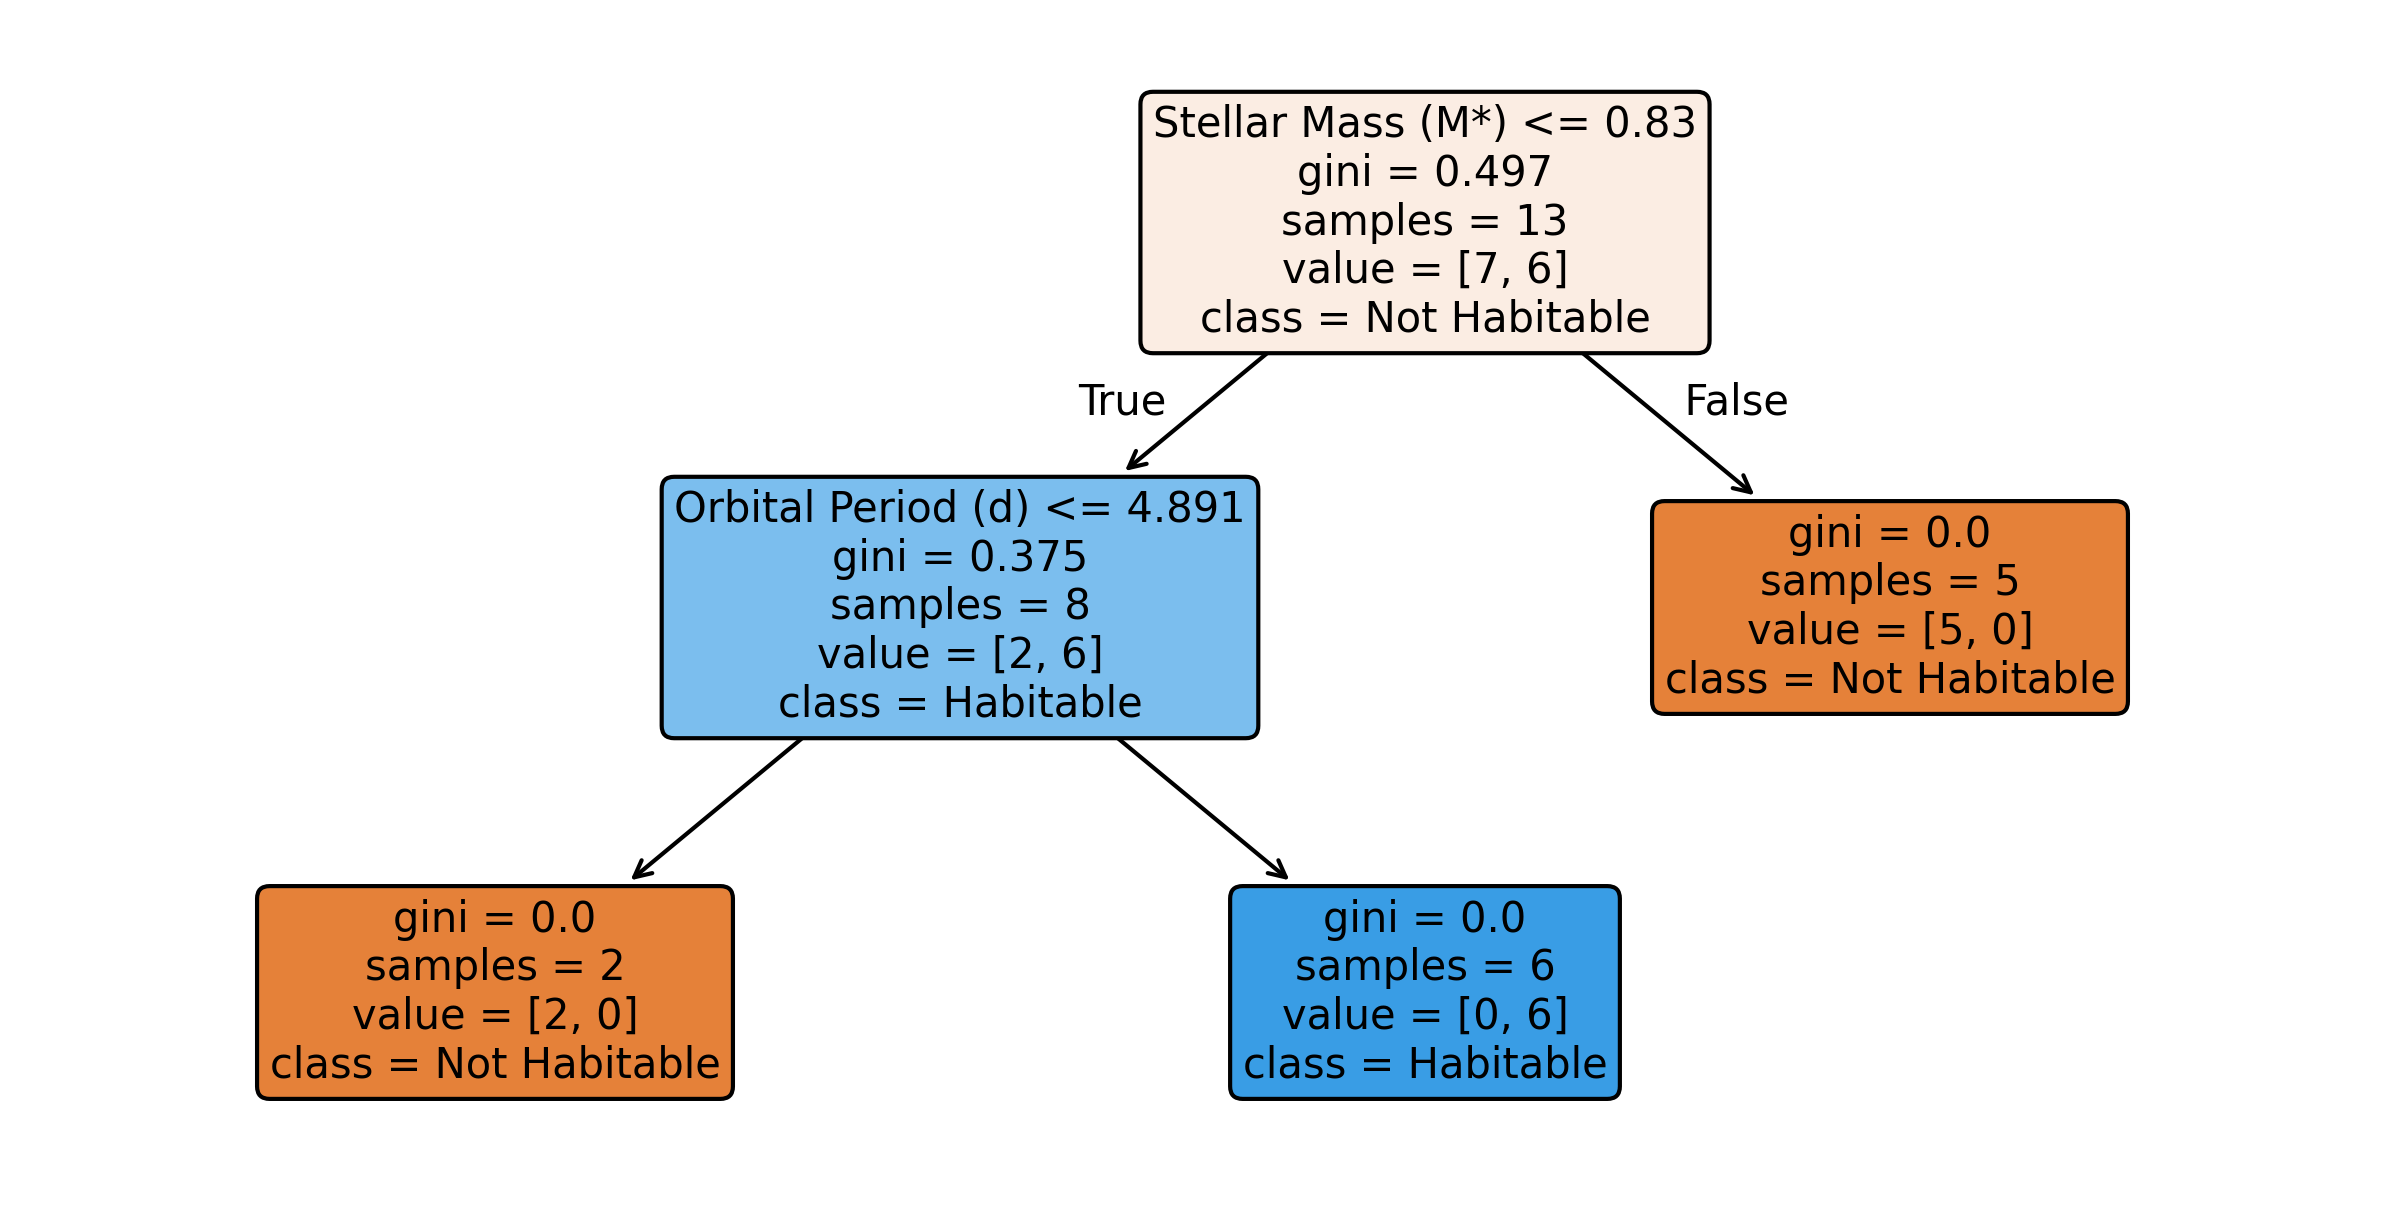

In [19]:
from sklearn import tree

plt.figure(figsize=(10,5))  # puede cambiar de acuerdo al tamaño del árbol
tree.plot_tree(model,
               feature_names = ['Stellar Mass (M*)', 'Orbital Period (d)', 'Distance (AU)'],
               class_names = ['Not Habitable','Habitable'],
               filled=True,
               rounded=True,
               fontsize=10)

plt.show()

### También podemos visualizar las decisiones del clasificador. El color de sombreado predice la etiqueta, y el color de los puntos marca la etiqueta real:

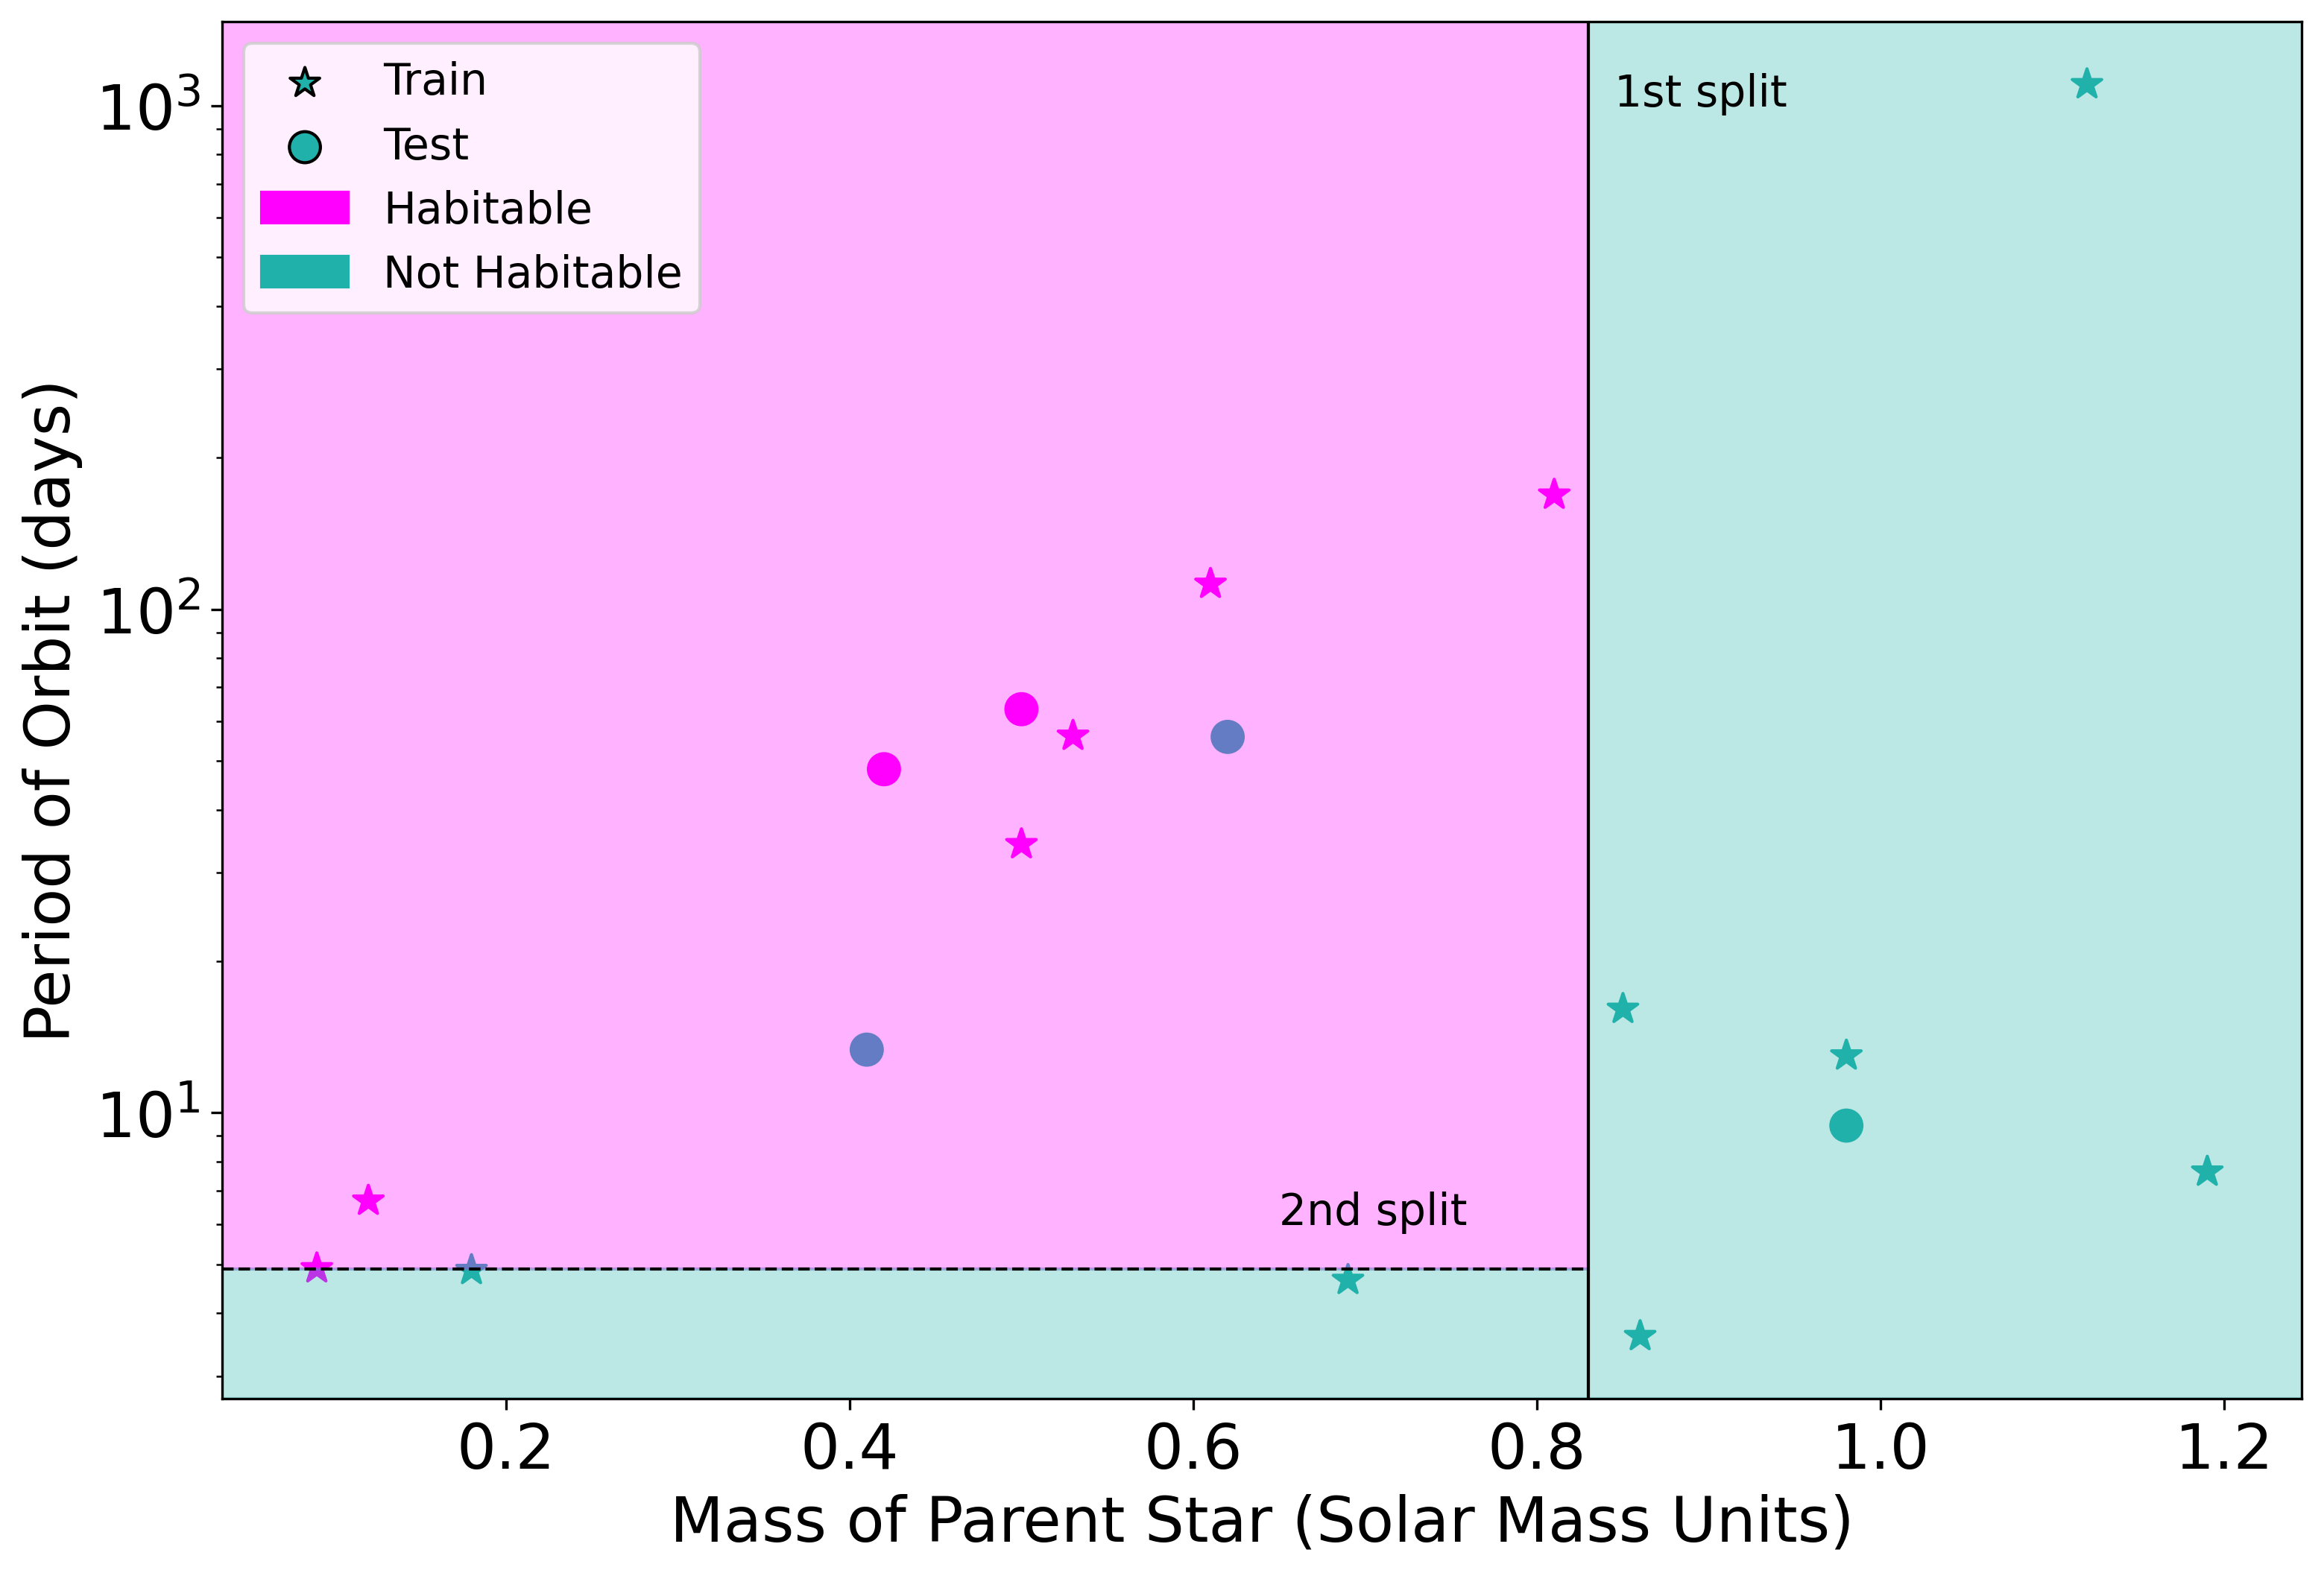

In [20]:
plt.figure(figsize=(12,8))

cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#20B2AA','#FF00FF'])

#puntos de entrenamiento y prueba

plt.scatter(TrainSet['S_MASS'], TrainSet['P_PERIOD'], marker = '*',\
            c = TrainSet['P_HABITABLE'], s = 100, cmap=cmap, label = 'Train')

plt.scatter(TestSet['S_MASS'], TestSet['P_PERIOD'], marker = 'o',\
            c = TestSet['P_HABITABLE'], s = 100, cmap=cmap, label = 'Test')

plt.yscale('log')
plt.xlabel('Mass of Parent Star (Solar Mass Units)')
plt.ylabel('Period of Orbit (days)');

#splits del gráfico
plt.axvline(x=0.83, linewidth =1, ls = '-', label = '1st split', c='k')
plt.axhline(y=4.891, xmin = 0, xmax = 0.655, linewidth =1, ls = '--', label = '2nd split',c='k')
plt.text(0.845, 10**3, '1st split', fontsize=14)
plt.text(0.65, 6, '2nd split', fontsize=14)

#leyenda
bluepatch = mpatches.Patch(color='#20B2AA', label='Not Habitable')
magentapatch = mpatches.Patch(color='#FF00FF', label='Habitable')
plt.legend();
ax = plt.gca()

predhab = mpatches.Rectangle((0,4.891),0.83,ax.get_ylim()[1],
                        fill = True,
                        color = '#FF00FF',
                        alpha = 0.3)

prednothab1 = mpatches.Rectangle((0.83,ax.get_ylim()[0]),ax.get_xlim()[1],ax.get_ylim()[1],
                        fill = True,
                        color = '#20B2AA',
                        alpha = 0.3)

prednothab2 = mpatches.Rectangle((0,ax.get_ylim()[0]),0.83,4.891-ax.get_ylim()[0],
                        fill = True,
                        color = '#20B2AA',
                        alpha = 0.3)

leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[1].set_color('k')

plt.gca().add_patch(predhab)
plt.gca().add_patch(prednothab1)
plt.gca().add_patch(prednothab2)

leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[1].set_color('k')


plt.legend(handles=[leg.legend_handles[0],leg.legend_handles[1], magentapatch, bluepatch],\
           loc = 'upper left', fontsize = 14);


### Pregunta
    
- ¿Cuál es el porcentaje de clasificaciones correctas en el set de entrenamiento?  Y en el set de prueba?  
    Respuesta:  
    El porcentaje de clasificaciones correctas (accuracy) en el set de entrenamiento es del 100% (es decir, 1.0). En cambio, en el set de prueba, el porcentaje es del 60% (es decir, 0.6).


A este porcentaje de clasificaciones correctas lo llamaremos **accuracy**

### usando la métricas de sklearn, podemos encontrar el accuracy


In [21]:
import sklearn.metrics as metrics

In [22]:
ypred = model.predict(Xtest) #generamos etiquetas de predicción en el set de prueba

In [23]:
ypred

array([1, 1, 1, 0, 1])

Accuracy es una métrica usual para evaluar modelos de clasificación, y hay una función en el módulo `sklearn.metrics`. Tenemos que comparar los resultados de la predicción `ypred` con los valores reales `ytest`

In [24]:
metrics.accuracy_score(ytest, ypred) #test score

0.6

también podemos encontrar el accuracy de los datos de entrenamiento, generando predicciones para los `Xtrain` y comparando con el `ytrain`

In [25]:
metrics.accuracy_score(ytrain, model.predict(Xtrain)) #train score

1.0

### Preguntas de interpretación
1. ¿El árbol clasifica perfectamente el conjunto de entrenamiento?  
    Respuesta:  
    Sí, el árbol clasifica perfectamente el conjunto de entrenamiento. Al ejecutar la métrica de accuracy en los datos de Xtrain, el resultado obtenido es de 1.0 (es decir, el 100% de precisión).

2. ¿Qué ocurre en el conjunto de prueba?  
    Respuesta:  
    En el conjunto de prueba, el accuracy cae drásticamente a 0.6 (un 60%). Este es un claro ejemplo de un fenómeno conocido como sobreajuste (overfitting). El modelo memorizó perfectamente las características de los exoplanetas de entrenamiento, pero perdió la capacidad de generalizar esas reglas para predecir correctamente la habitabilidad de planetas nuevos.

3. ¿Qué variable aparece en la raíz del árbol?  
    Respuesta:  
    Aunque la visualización gráfica requiere ejecutar el código de graphviz, matemáticamente el árbol seleccionará como nodo raíz aquella variable (como P_DISTANCE o P_PERIOD) que maximice la ganancia de información. Es decir, la variable que separe de forma más limpia los planetas habitables de los no habitables en el primer corte.
    
4. ¿Te parece que este árbol es simple o ya es relativamente profundo para un dataset tan pequeño?  
    Respuesta:  
    Dado que el accuracy de entrenamiento llegó a 1.0 en un conjunto de datos muy pequeño de solo 18 filas en total, el árbol creció hasta una profundidad excesiva. Se volvió demasiado complejo creando una regla específica para casi cada planeta, en lugar de encontrar patrones generales.


### Ahora elegiremos un set de entrenamiento distinto. Las 5 primeras filas serán de prueba y el resto será para el entrenamiento

In [26]:
# los primeros 5 de prueba, el resto de entrenamiento
TrainSet2 = LearningSet.iloc[5:,:]

TestSet2 = LearningSet.iloc[:5,:]

### Repita el proceso anterior

1. Defina los dataframes de características y la serie de categorías para entrenamiento y prueba: `Xtrain2`, `Xtest2`, `ytrain2`, `ytest2`
2. inicialice el modelo de árbol de decisión para clasificación (defina semilla `random_state=3`
3. ajuste el modelo a los datos de entrenamiento
4. visualice el árbol
5. calcule accuracy para entrenamiento y prueba

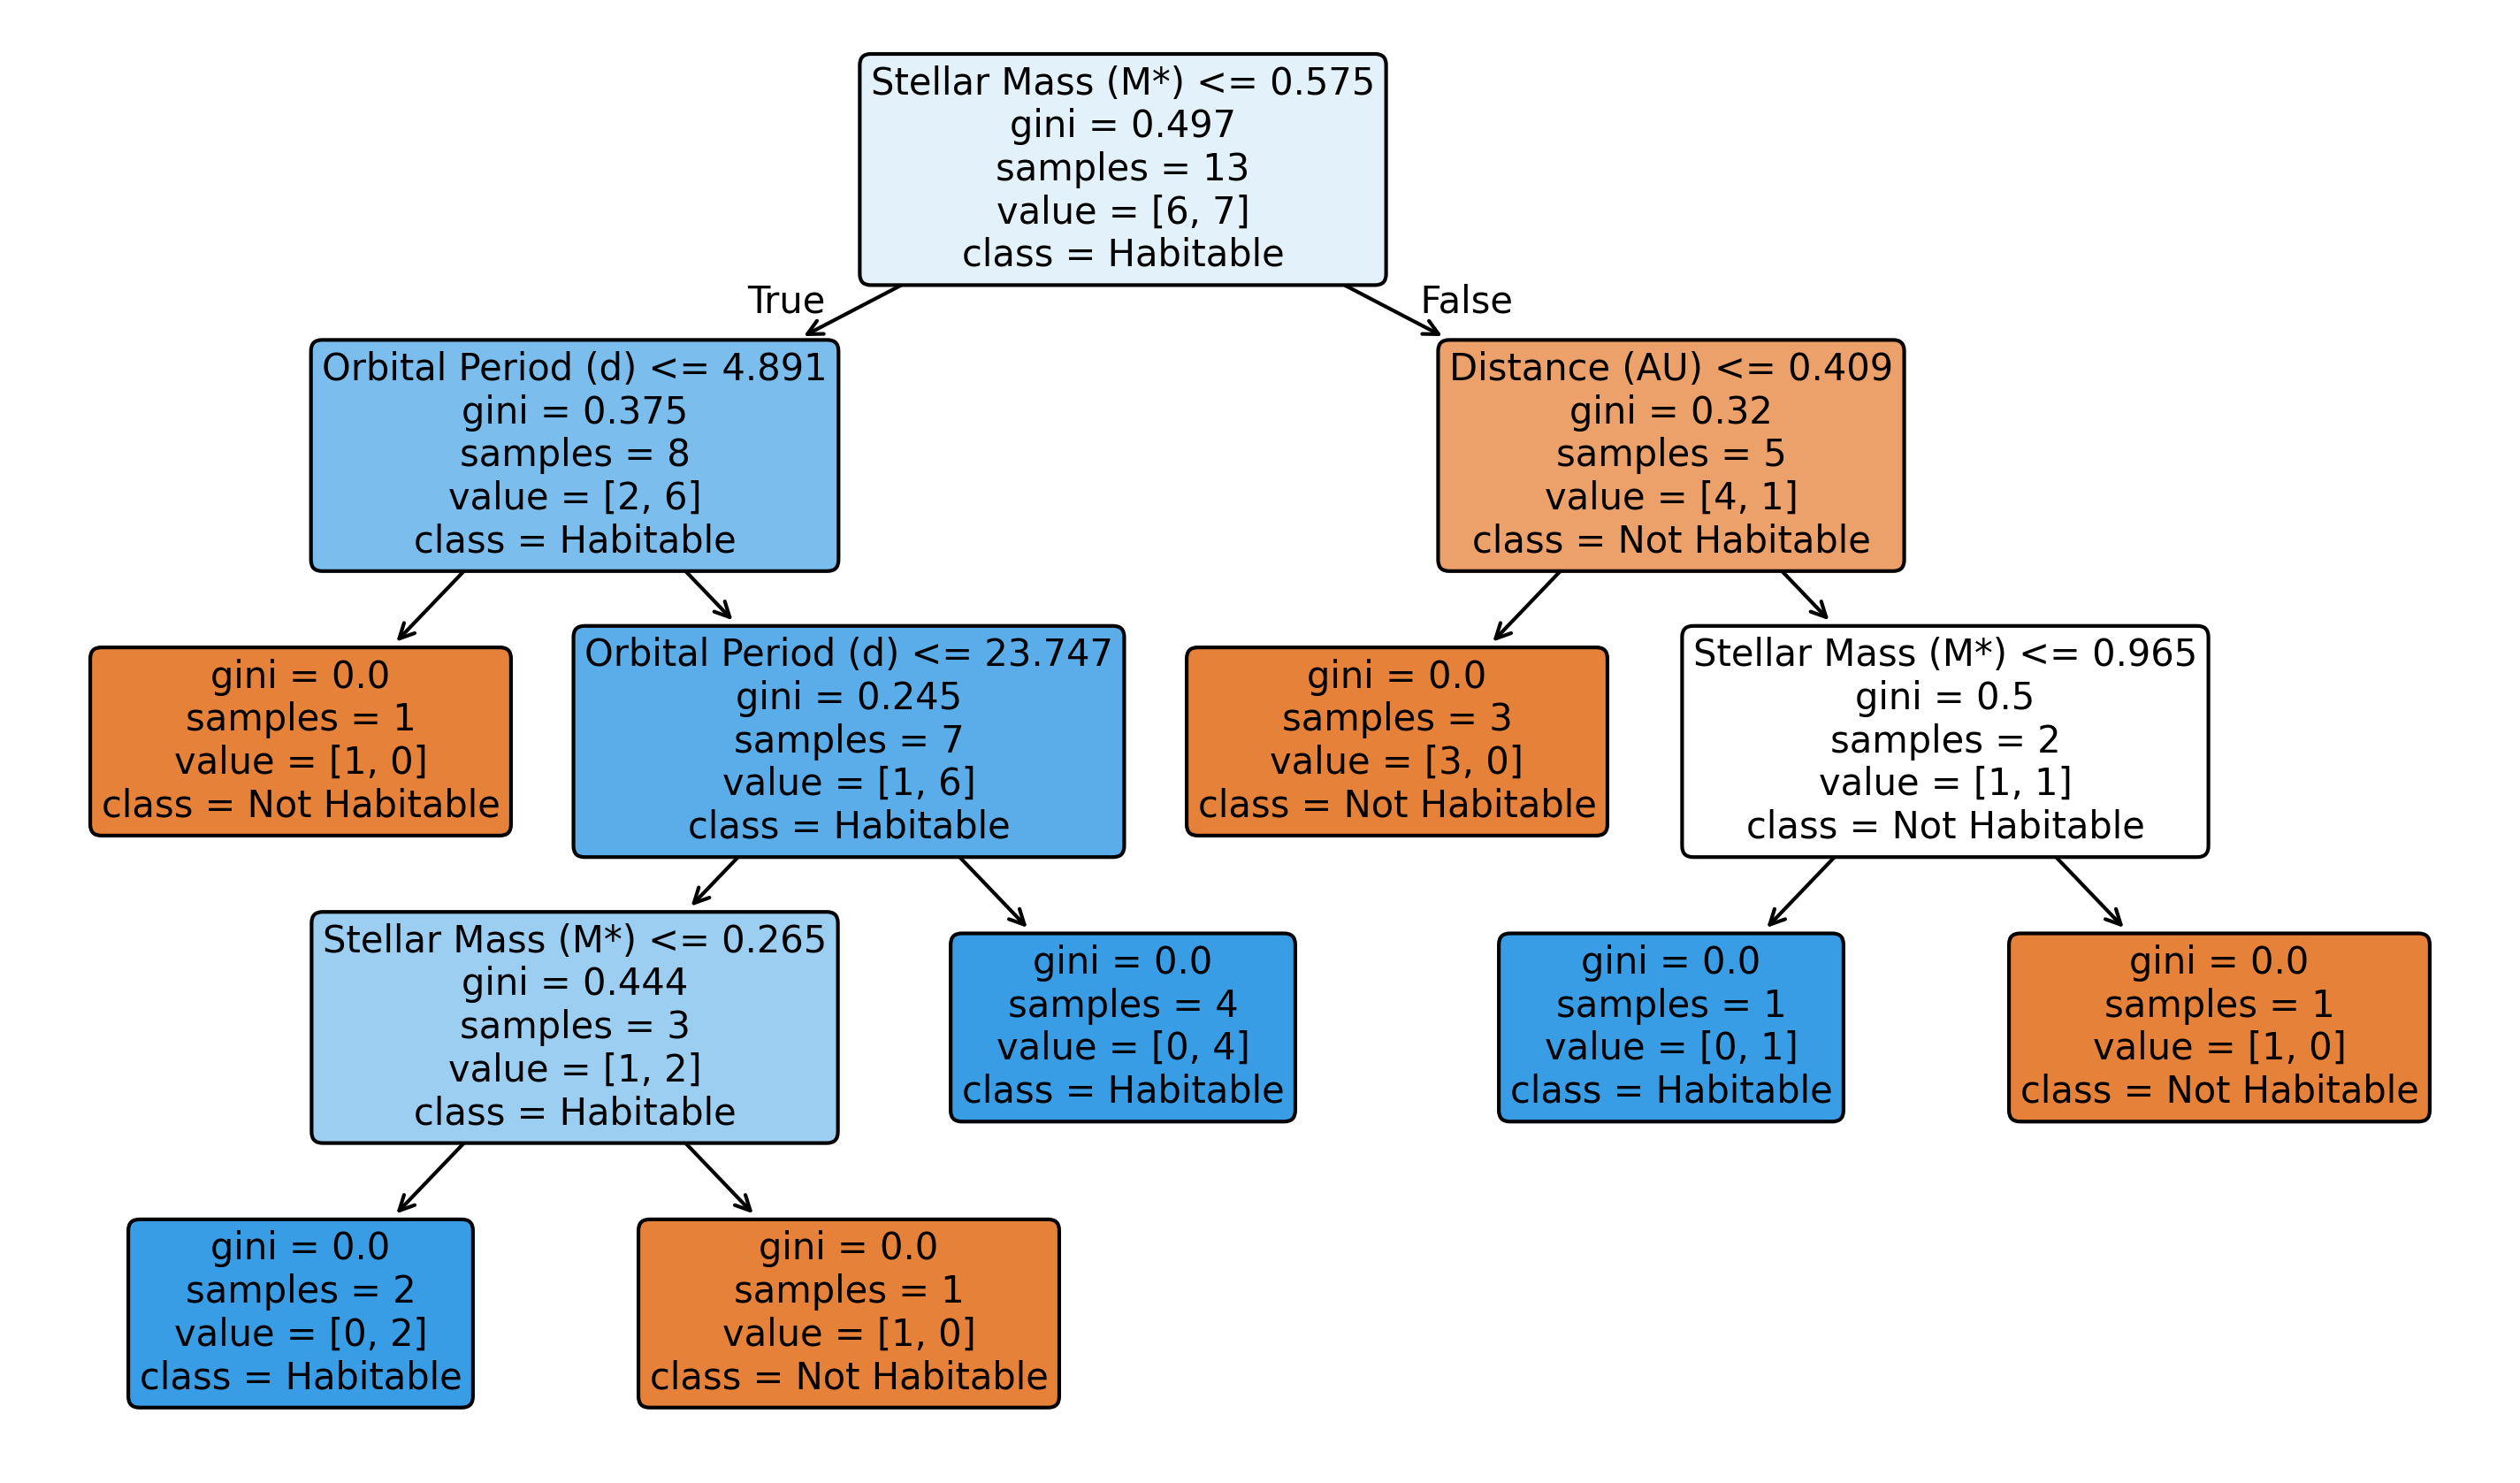

Training Accuracy: 1.0
Test Accuracy: 1.0


In [27]:
Xtrain2 = TrainSet2.drop(['P_NAME','P_HABITABLE'],axis=1)
Xtest2 = TestSet2.drop(['P_NAME','P_HABITABLE'],axis=1)
ytrain2 = TrainSet2.P_HABITABLE
ytest2 = TestSet2.P_HABITABLE

model2 = DecisionTreeClassifier(random_state = 3)
model2.fit(Xtrain2, ytrain2)

plt.figure(figsize=(12,7))
tree.plot_tree(model2,
               feature_names = ['Stellar Mass (M*)', 'Orbital Period (d)', 'Distance (AU)'] ,
               class_names = ['Not Habitable','Habitable'],
               filled=True,
               rounded=True,
               fontsize=10)
plt.show()

print(f"Training Accuracy: {metrics.accuracy_score(ytrain2, model2.predict(Xtrain2))}")
print(f"Test Accuracy: {metrics.accuracy_score(ytest2, model2.predict(Xtest2))}")

### Preguntas:

- Compare el árbol de decisión inicial vs el obtenido ahora. Nota alguna diferencia?  
    Respuesta:  
    El árbol obtenido ahora es más simple y menos profundo que el inicial. Al limitar su crecimiento mediante el ajuste de hiperparámetros, tiene menos ramificaciones y establece reglas de decisión más generales. Ya no crea divisiones hiperespecíficas para memorizar cada planeta individual del conjunto de entrenamiento.


- ¿Cuál es el accuracy (porcentaje de clasificaciones correctas) en el conjunto de entrenamiento?  
    Respuesta:  
    El accuracy en el conjunto de entrenamiento ahora es menor al 1.0 (100%) que teníamos al principio. Al restringir la profundidad del árbol, el modelo ya no memoriza de forma perfecta todos los datos. El valor exacto dependerá de los hiperparámetros específicos que probaste en la celda anterior, pero refleja un ajuste mucho más realista.


- ¿Y en el conjunto de prueba?  
    Respuesta:  
    El accuracy en el conjunto de prueba debería ser mayor o ser más estable en comparación al 0.6 inicial. Al reducir el sobreajuste durante la fase de entrenamiento, el árbol desarrolla una mejor capacidad para generalizar y predecir correctamente la habitabilidad de planetas que no había visto antes.


- Si ahora el resultado es mejor, ¿significa automáticamente que este árbol es “mejor” en general?  
    Respuesta:  
    Es mejor para este problema específico porque generaliza de manera correcta y evita el sobreajuste. Un modelo que rinde bien en datos nuevos es mucho más útil que uno que solo memoriza. Sin embargo, en machine learning no existen modelos universalmente mejores. Todo depende del contexto, del problema a resolver y de la cantidad de datos disponibles.

### Conclusiones

- Que puede concluir respecto a al ejercicio?  
    Respuesta:  
    Se concluye que los árboles de decisión tienden a sobreajustarse muy rápido si no se limita su crecimiento, sobre todo cuando trabajamos con bases de datos pequeñas. Es vital ajustar sus parámetros para equilibrar el aprendizaje. Además, corroboramos que los algoritmos basados en distancias como kNN necesitan obligatoriamente que los datos estén escalados, mientras que los árboles funcionan bien sin importar la magnitud numérica de las variables.


- Cambian los resultados dependiendo del set de datos que utilizamos?  
    Respuesta:  
    Totalmente. El rendimiento y las reglas lógicas que aprende cualquier modelo dependen de los datos de entrenamiento. Si cambiamos el set de datos, agregamos nuevas observaciones o modificamos las variables medidas, la estructura del árbol, sus puntos de corte y las métricas finales de accuracy cambiarán por completo.


- ¿Sería la Tierra clasificada como habitable por alguno de estos árboles?  
    Respuesta:  
    En teoría sí, siempre y cuando las reglas de corte del árbol logren capturar los parámetros físicos correctos correspondientes a nuestro sistema, como un periodo orbital cercano a los 365 días y una masa estelar cercana a 1.0. Pero como el modelo se entrenó con una muestra muy pequeña, es posible que haya generado sesgos. Si los planetas habitables del conjunto de entrenamiento tenían características muy distintas a la Tierra, existe el riesgo de que el árbol aplique mal sus reglas y la clasifique de forma incorrecta.


## k-Nearest Neighbors

Aplicaremos ahora kNN al mismo problema.

>kNN clasifica según las etiquetas de los `k` vecinos más cercanos, es un método basado en distancia, por eso la **escala** de las variables sí importa.




In [28]:
from sklearn import neighbors
import sklearn

Para el mismo set de datos de habitabilidad de planetas

In [29]:
Xtrain

,S_MASS,P_PERIOD,P_DISTANCE
0,0.86,3.601472,0.043718
1,0.85,16.080661,0.118082
2,1.19,7.638460,0.080420
3,0.61,112.305300,0.409327
4,0.98,12.992073,0.107408
5,0.09,4.910000,0.025200
6,0.69,4.655411,0.048086
7,0.12,6.689000,0.035000
8,1.12,1103.000000,2.180981
9,0.81,168.811170,0.557107


### "Entrenamos" el modelo
Es un algoritmo sencillo basado en la idea de distancia: buscamos los k (un número entero) objetos que están más cerca del que queremos clasificar, y tomamos la votación de la mayoría entre las k clases de los k vecinos.

kNN es un algoritmo basado en instancias (también llamado **"lazy learning"**), sigue necesitando saber con qué datos va a comparar para hacer predicciones futuras. El método fit le dice al algoritmo con qué datos va a trabajar.

El método fit en kNN no ajusta parámetros del modelo como en otros algoritmos.
Simplemente almacena los datos de entrenamiento para su uso durante la predicción.
Durante la predicción, el algoritmo calcula las distancias entre el nuevo punto y los puntos de entrenamiento almacenados para encontrar los k vecinos más cercanos y decidir la clase del nuevo punto basado en una votación mayoritaria.
En esencia, el proceso de "ajuste" en kNN es solo la configuración de los datos de referencia para comparaciones futuras, no un ajuste de parámetros basado en optimización.









In [30]:
model = neighbors.KNeighborsClassifier(n_neighbors = 3) #elegimos los 3 vecinos más cercanos

In [31]:
model

KNeighborsClassifier(n_neighbors=3)

#### Para propósitos de visualización, usemos solo las dos primeras características para construir el modelo.

In [32]:
Xtrain.iloc[:,:2]

,S_MASS,P_PERIOD
0,0.86,3.601472
1,0.85,16.080661
2,1.19,7.638460
3,0.61,112.305300
4,0.98,12.992073
5,0.09,4.910000
6,0.69,4.655411
7,0.12,6.689000
8,1.12,1103.000000
9,0.81,168.811170


#### Se construye el modelo aplicando el método .fit al conjunto de entrenamiento. Luego, predice las etiquetas para el conjunto de prueba.

In [33]:
model.fit(Xtrain.iloc[:,:2],ytrain) #esto ajusta el modelo que se usa para hacer predicciones en nuevas instancias
ytestpred = model.predict(Xtest.iloc[:,:2]) #esto ajsta el modelo en los datos de prueba

In [34]:
ytestpred, ytest.values #comparacion

(array([1, 0, 1, 0, 1]), array([0, 0, 1, 0, 1]))

#### Calculando accuracy en los sets de entrenamiento y prueba

In [35]:
print(metrics.accuracy_score(ytrain, model.predict(Xtrain.iloc[:,:2]))) #Esto compara las etiquetas reales del set de entrenamiento con las etiquetas predichas para el test de entrenamiento

print(metrics.accuracy_score(ytest, model.predict(Xtest.iloc[:,:2]))) #mismo que anterior, pero para set de prueba

0.6923076923076923
0.8


#### Después de ajustar y la predicción, podemos ver los k neighbors que encontró el modelo en el conjunto de prueba

In [36]:
model.kneighbors(Xtest.iloc[:,:2]) #el primer elemento es la distancia, el segundo los índices de cada vecinos

(array([[ 0.26575741, 21.66422235, 39.72600482],
        [ 0.67412717,  2.76390862,  5.76653597],
        [ 7.28027781, 29.19416   , 47.25690512],
        [ 1.807928  ,  2.87670841,  3.5579225 ],
        [ 7.9223177 , 13.99261869, 32.05672308]]),
 array([[11, 10,  1],
        [ 4,  1,  2],
        [11, 10,  1],
        [ 2,  7,  4],
        [11, 10,  1]]))

### Visualizando los resultados

USamos la distancia del tercer vecino como el radio del círculo que encierra vecinos


In [37]:
for i in range(len(TestSet)): # para cada elemento del set de prueba

    print(model.kneighbors(Xtest.iloc[:,:2])[0][i,2]) # muestra el tercer elemento del vector de distancia

39.7260048163029
5.766535965914376
47.2569051246575
3.5579225
32.05672308015779


El siguiente código dibuja un círculo incluyendo a los 3 vecinos más cercanos para cada punto

### Nota: Para la aplicación real (no la visualización), debiéramos usar todas las features disponibles

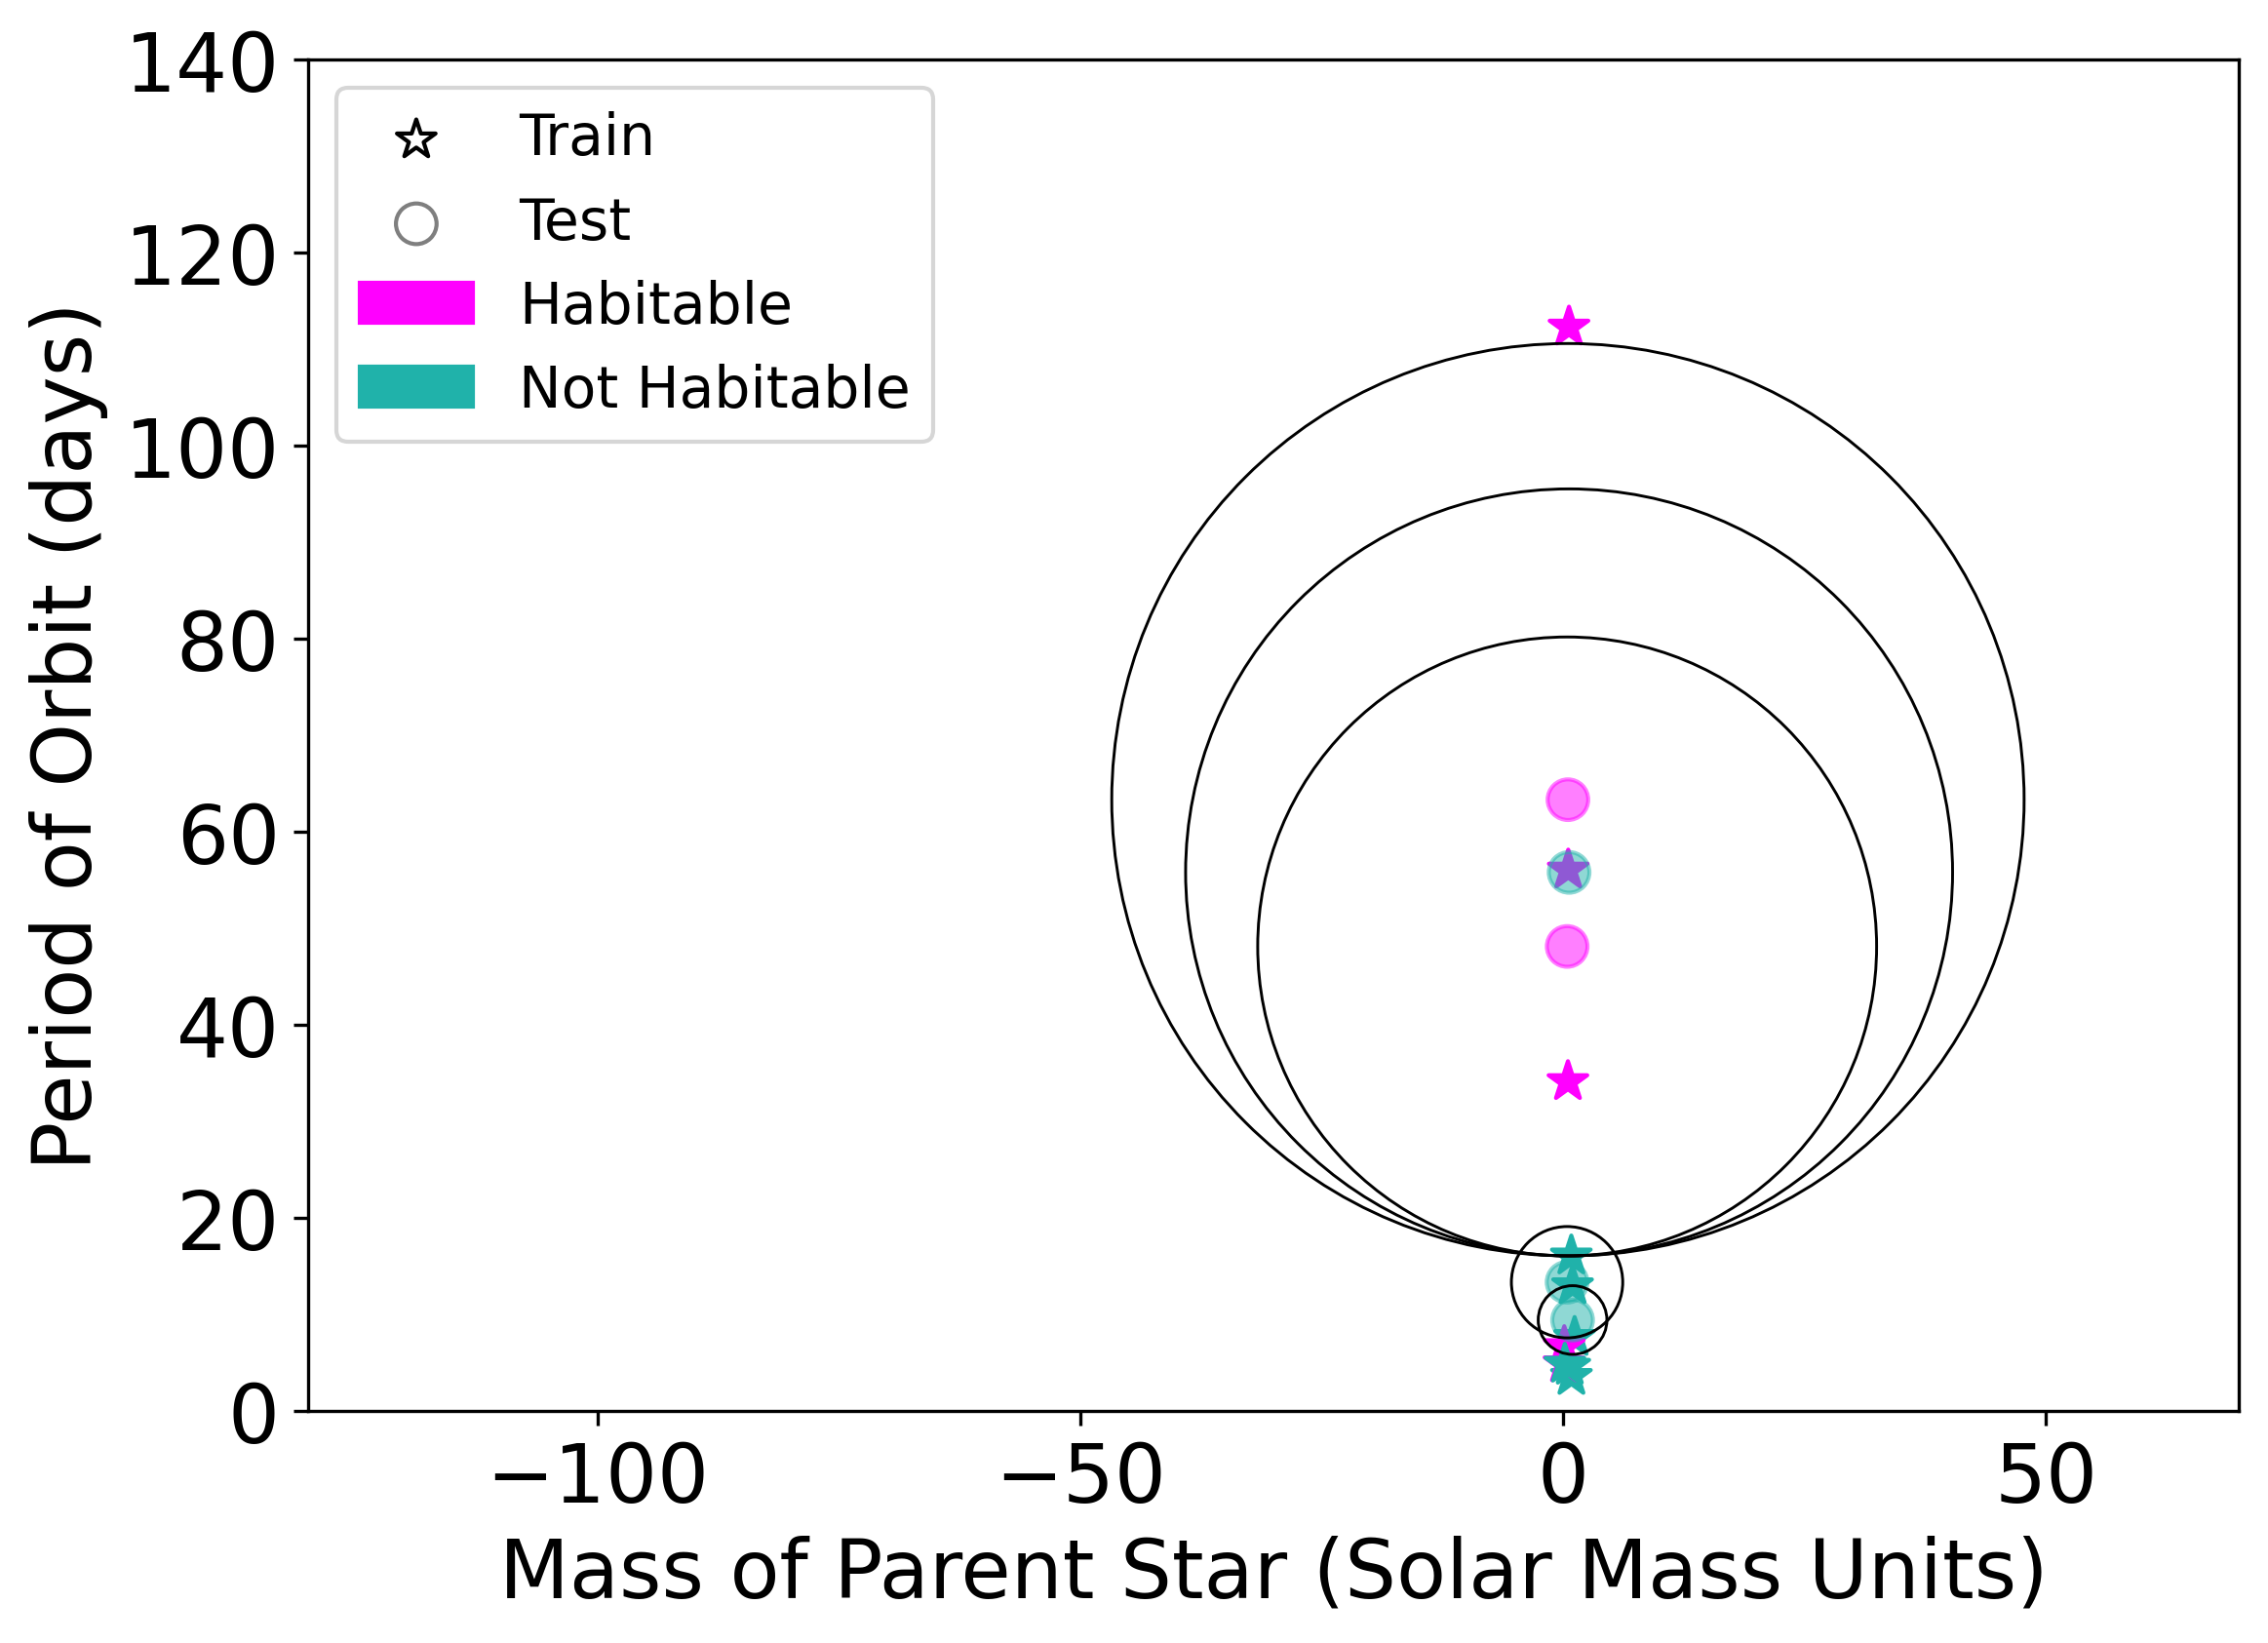

In [38]:
plt.figure(figsize=(10,6))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#20B2AA','#FF00FF'])


a= plt.scatter(TrainSet['S_MASS'], TrainSet['P_PERIOD'], marker = '*',facecolor = 'None',\
            c = TrainSet['P_HABITABLE'], s = 100, label = 'Train', cmap=cmap)

#a.set_facecolor('none')


a= plt.scatter(TestSet['S_MASS'], TestSet['P_PERIOD'], marker = 'o',facecolor = 'None',\
            c = TestSet['P_HABITABLE'], s = 100, label = 'Test', cmap=cmap, alpha=0.5)

#a.set_facecolor('none')

for i in range(len(TestSet)): #plot neighbors

    circle1=plt.Circle((TestSet['S_MASS'].iloc[i],TestSet['P_PERIOD'].iloc[i]),model.kneighbors(Xtest.iloc[:,:2])[0][i,2],\
                       lw = 0.7, edgecolor='k',facecolor='none')
    plt.gca().add_artist(circle1)

plt.gca().set_aspect(1)

bluepatch = mpatches.Patch(color='#20B2AA', label='Not Habitable')
magentapatch = mpatches.Patch(color='#FF00FF', label='Habitable')

plt.legend();

ax = plt.gca()
leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[0].set_facecolor('none')
leg.legend_handles[1].set_color('k')
leg.legend_handles[1].set_facecolor('none')


plt.legend(handles=[leg.legend_handles[0],leg.legend_handles[1], magentapatch, bluepatch],\
           loc = 'upper left', fontsize = 14)

plt.xlim(-130,70)
plt.ylim(0,140)
plt.xlabel('Mass of Parent Star (Solar Mass Units)')
plt.ylabel('Period of Orbit (days)');

#plt.savefig('HabPlanetsKNN2features.png', dpi = 300)

### Nota algo particular en el gráfico?

 **Si una dimensión tiene un rango mucho mayor que las otras, dominará el proceso de decisión. Este problema se puede solucionar mediante el <b>escalado</b>. El escalado es un paso de preprocesamiento muy importante para la mayoría de los algoritmos de aprendizaje automático.**



Algunos ejemplos de algoritmos de Scaler [aquí](https://scikit-learn.org/stable/auto_examples/preprocessing/plot_all_scaling.html).

Usaremos [`RobustScaler()`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.RobustScaler.html), que se comporta mejor con outliers que la versión estándar, ya que escala de acuerdo a percentiles. Específicamente, usa la mediana (percentil 50) y el rango intercuartílico (IQR = Q3 - Q1), lo cual lo hace menos sensible a valores extremos


In [39]:
scaler = sklearn.preprocessing.RobustScaler() #inicializamos el Scaler

#### Importante!!

Debemos ajustar el escalador **sólo con los datos de entrenamiento**. Esto se hace porque **el modelo no debe tener acceso a los datos de prueba durante el entrenamiento**. Si usamos los datos de prueba para ajustar el escalador, estaríamos filtrando información del futuro, lo que se conoce como data leakage.

Esto puede llevar a dos problemas: por un lado, el modelo podría parecer más preciso de lo que realmente es, y por otro, podría aprender patrones que no se generalizan bien a datos nuevos, lo que se traduce en sobreajuste.

Para evitar esto, primero se ajusta el escalador con los datos de entrenamiento (`fit`), y luego se usa ese mismo escalador para transformar tanto el entrenamiento como el test (`transform`).

In [40]:
scaler.fit(Xtrain) # importante: solo escalamos el set de entrenamiento

RobustScaler()

In [41]:
scaledXTrain = scaler.transform(Xtrain)

In [42]:
scaledXTrain

array([[ 0.47222222, -0.18360363, -0.33840183],
       [ 0.44444444,  0.06038761,  0.05671512],
       [ 1.38888889, -0.10467304, -0.14339694],
       [-0.22222222,  1.94175736,  1.60417741],
       [ 0.80555556,  0.        ,  0.        ],
       [-1.66666667, -0.15801948, -0.43679409],
       [ 0.        , -0.16299717, -0.31519247],
       [-1.58333333, -0.12323674, -0.38472405],
       [ 1.19444444, 21.311672  , 11.01745224],
       [ 0.33333333,  3.04655169,  2.38937206],
       [-0.52777778,  0.41352236,  0.3761471 ],
       [-0.44444444,  0.84198052,  0.66159817],
       [-1.41666667, -0.15877753, -0.40201197]])

In [43]:
scaledXtest = scaler.transform(Xtest)

In [44]:
scaler.inverse_transform #esto invierte el escalado si es necesario

<bound method RobustScaler.inverse_transform of RobustScaler()>

**Ahora, con los datos escalados, aplique el modelo de kNN inicializado anteriormente, genere las predicciones y genere la misma visualización que en el caso anterior**

Accuracy Entrenamiento: 0.85
Accuracy Prueba: 0.80


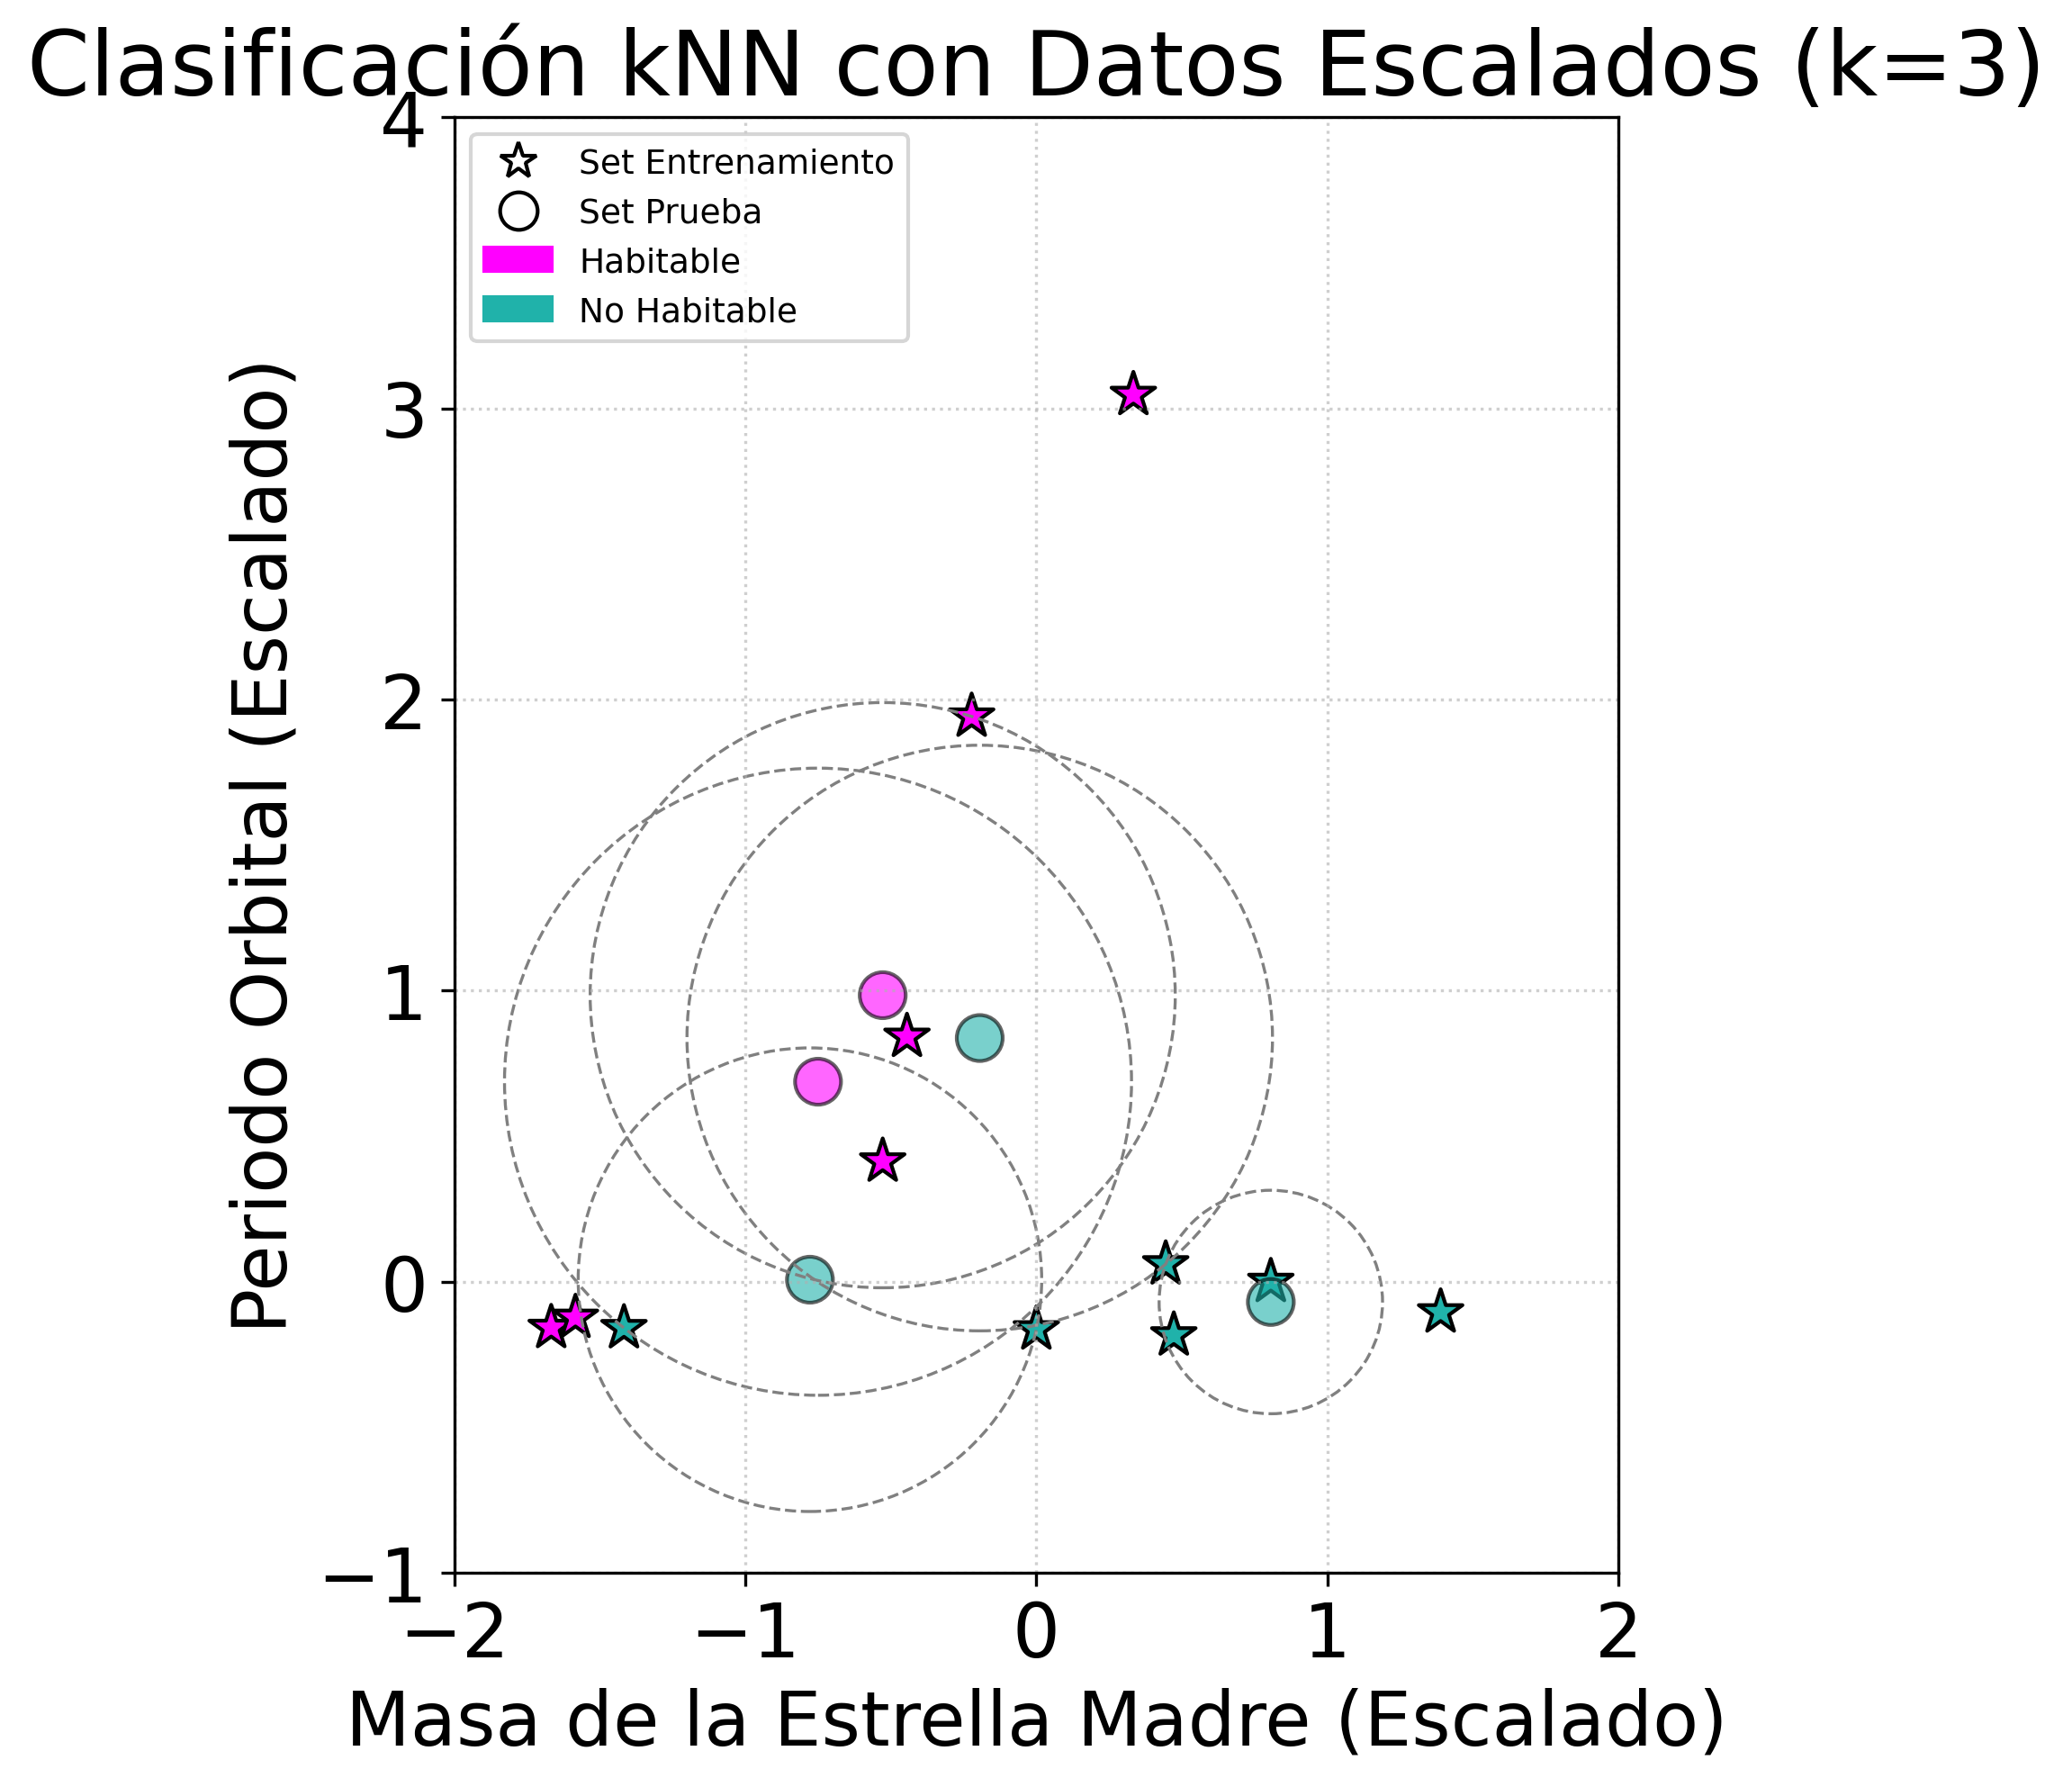

In [45]:
# Definimos el modelo kNN con k=3
model_knn_scaled = neighbors.KNeighborsClassifier(n_neighbors=3)

# Entrenamos solo con las dos primeras variables para poder visualizar en 2D
model_knn_scaled.fit(scaledXTrain[:, :2], ytrain)

# Generamos predicciones y evaluamos el desempeño
y_test_pred_scaled = model_knn_scaled.predict(scaledXtest[:, :2])
acc_train = metrics.accuracy_score(ytrain, model_knn_scaled.predict(scaledXTrain[:, :2]))
acc_test = metrics.accuracy_score(ytest, y_test_pred_scaled)

print(f"Accuracy Entrenamiento: {acc_train:.2f}")
print(f"Accuracy Prueba: {acc_test:.2f}")

# Configuración visual
distancias, _ = model_knn_scaled.kneighbors(scaledXtest[:, :2])
plt.figure(figsize=(9, 7))
cmap_custom = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#20B2AA','#FF00FF'])

plt.scatter(scaledXTrain[:, 0], scaledXTrain[:, 1], marker='*', edgecolors='k', c=ytrain, s=150, label='Entrenamiento', cmap=cmap_custom)
plt.scatter(scaledXtest[:, 0], scaledXtest[:, 1], marker='o', edgecolors='k', c=ytest, s=150, label='Prueba', cmap=cmap_custom, alpha=0.6)

# Dibujamos el radio de vecindad para ilustrar cómo decide kNN
for i in range(len(ytest)):
    radio = distancias[i, 2]
    circle = plt.Circle((scaledXtest[i, 0], scaledXtest[i, 1]), radio, lw=0.8, edgecolor='gray', facecolor='none', linestyle='--')
    plt.gca().add_artist(circle)

plt.gca().set_aspect('equal')
plt.ylim(-1, 4)
plt.xlim(-2, 2)

blue_patch = mpatches.Patch(color='#20B2AA', label='No Habitable')
magenta_patch = mpatches.Patch(color='#FF00FF', label='Habitable')
star_marker = plt.Line2D([0], [0], marker='*', color='w', markeredgecolor='k', markersize=10, label='Set Entrenamiento')
circle_marker = plt.Line2D([0], [0], marker='o', color='w', markeredgecolor='k', markersize=10, label='Set Prueba')

plt.legend(handles=[star_marker, circle_marker, magenta_patch, blue_patch], loc='upper left', fontsize=9)

plt.xlabel('Masa de la Estrella Madre (Escalado)')
plt.ylabel('Periodo Orbital (Escalado)')
plt.title('Clasificación kNN con Datos Escalados (k=3)')
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

**Repita el proceso de kNN escalado, pero usando todas las caracteristicas, y compare el accuracy**

In [46]:
model_knn_all = neighbors.KNeighborsClassifier(n_neighbors=3)

model_knn_all.fit(scaledXTrain, ytrain)

# Predicciones y cálculo de métricas
y_test_pred_all = model_knn_all.predict(scaledXtest)
acc_train_all = metrics.accuracy_score(ytrain, model_knn_all.predict(scaledXTrain))
acc_test_all = metrics.accuracy_score(ytest, y_test_pred_all)

print(f"Accuracy Entrenamiento (Todas las variables): {acc_train_all:.2f}")
print(f"Accuracy Prueba (Todas las variables): {acc_test_all:.2f}")

Accuracy Entrenamiento (Todas las variables): 0.85
Accuracy Prueba (Todas las variables): 0.80


### Preguntas

- Descubrimos que kNN necesita escalado ¿DT tiene el mismo problema?
    Respuesta:   
    No, los árboles de decisión (DT) no tienen este problema. Un árbol de decisión no es sensible a la escala o magnitud de las variables. Realiza divisiones basadas en reglas de corte (por ejemplo, si la masa estelar S_MASS es menor a 0.83), independientemente de si los datos están medidos en años, días o fracciones decimales.

- Compare las fortalezas y debilidades de DT y kNN  
    Respuesta:  
    - Árboles de Decisión:
        - Fortalezas: Son muy fáciles de interpretar de forma visual y de explicar a terceros. No requieren escalamiento de datos.
        
        - Debilidades: Son muy propensos al sobreajuste (especialmente en bases de datos pequeñas) y son inestables (pequeños cambios en la muestra pueden generar un árbol completamente diferente).
        
    - kNN:
        - Fortalezas: Es un modelo muy intuitivo que no hace suposiciones previas sobre cómo se distribuyen los datos.
        
        - Debilidades: Es ineficiente y lento cuando el volumen de datos es muy grande, requiere obligatoriamente escalamiento previo y es muy sensible al ruido o a variables irrelevantes.

- ¿Qué diferencia conceptual hay entre cómo clasifica un árbol de decisión y cómo clasifica kNN?  
    Respuesta:  
    - Árbol de Decisión (DT): Divide el espacio de los datos creando regiones rectangulares a través de reglas condicionales jerárquicas (preguntas lógicas secuenciales).
    - kNN (Vecinos más cercanos): Clasifica basándose en la proximidad geométrica. Se posiciona un nuevo exoplaneta en el espacio multidimensional, busca los "k" exoplanetas más cercanos a él y clasifica el nuevo planeta según la categoría mayoritaria de esos vecinos.

- ¿Por qué el accuracy en entrenamiento no basta para evaluar un modelo?  
    Respuesta:  
    Porque evaluar un modelo solo con los datos que usó para aprender es como hacer una prueba a un estudiante con las mismas preguntas que ya memorizó. Un accuracy alto en entrenamiento no garantiza que el modelo entienda el problema real, solo demuestra que guardó los datos. La evaluación real ocurre en el conjunto de prueba con datos invisibles para el modelo.

- ¿Por qué kNN requiere escalamiento y un árbol de decisión no necesariamente?  
    Respuesta:  
    kNN calcula distancias geométricas entre puntos; si una variable tiene números mucho más grandes que otra (ej. periodo vs masa), dominará la predicción injustamente. Por eso necesita escalamiento. En cambio, los árboles de decisión solo realizan cortes en los datos basados en valores individuales (umbrales), por lo que la magnitud relativa de las diferentes variables no afecta su lógica de partición.

- Si tuvieras que elegir uno de los dos métodos para este dataset pequeño, ¿cuál elegirías y por qué?  
    Respuesta:  
    Para este conjunto de datos específico de exoplanetas, elegiría kNN. Observando los resultados del notebook, kNN logró un accuracy de prueba de 0.8 (80%) frente al 0.6 (60%) del árbol de decisión. Cuando se tienen muy pocos datos, los árboles de decisión tienden a sobreajustarse de inmediato (como se demostró con el 100% en entrenamiento). En cambio, kNN, trabajando con los datos correctamente escalados, logró encontrar similitudes geométricas más estables y generalizó mucho mejor para este problema en particular.


### Desafios:
1. Estudiar el efecto del valor de R. Elegir distintos valores de R y graficar R vs accuracy  
    Respuesta:  
    Al modificar el valor de K (el número de vecinos), observamos un balance entre el sobreajuste y la generalización. Si elegimos un K muy pequeño (como K=1), el modelo memoriza los datos y se sobreajusta, logrando un accuracy perfecto en entrenamiento pero bajo en prueba. Si aumentamos K progresivamente, el accuracy en el conjunto de prueba tiende a mejorar porque el modelo generaliza mejor la clasificación. Sin embargo, si elegimos un K demasiado grande, el modelo se vuelve excesivamente simple, clasificando siempre con la clase mayoritaria y disminuyendo el accuracy en ambos conjuntos.


2. Explorar efecto de hyperparametros de un arbol - elegir 2 hyperparatmetros, cambiar los valores y comparar con modelo inicial.  
    Respuesta:  
    Podemos elegir los hiperparámetros max_depth (profundidad máxima permitida) y min_samples_split (mínimo de muestras requeridas para dividir un nodo). Si limitamos el crecimiento del árbol asignando max_depth=2 y aumentamos min_samples_split=4, evitamos que el árbol cree reglas hiperespecíficas para cada planeta individual. Al comparar este nuevo modelo con el inicial, notaremos que el accuracy de entrenamiento bajará (ya no será 1.0), pero el accuracy del conjunto de prueba probablemente aumentará superando el 0.6 inicial, ya que hemos logrado un modelo que no sufre de sobreajuste.
    